In [205]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
import os
import torch
import csv
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from scipy import stats
from scipy.integrate import cumulative_trapezoid
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
import optuna
from skrebate import ReliefF
from scipy import stats as scipy_stats

In [206]:
def load_data(dataset_root='../FORTH_TRACE_DATASET', save_path='all_data.npy'):
    # Se o arquivo já existe, lê direto
    if os.path.exists(save_path):
        print("A carregar os dados do arquivo salvo...")
        return np.load(save_path)
    
    print("A ler os dados do CSV...")
    data_rows = []
    for part_id in range(15):
        dataset_path = f"{dataset_root}/part{part_id}"
        participant_id = part_id
        for dev_id in range(1, 6):
            csv_file = f"{dataset_path}/part{part_id}dev{dev_id}.csv"
            with open(csv_file, 'r', newline='') as f:
                reader = csv.reader(f, delimiter=',')
                for row in reader:
                    arr = np.array(row, dtype=float)
                    new_row = np.hstack((np.array([participant_id], dtype=float), arr))
                    data_rows.append(new_row)

    data = np.vstack(data_rows)
    
    # Salva em .npy para carregar rápido na próxima vez
    np.save(save_path, data)
    print(f"Dados salvos em {save_path}")
    
    return data

# Usar a função
data = load_data()
print(data[:5])
# Carregar dados
data = np.load('all_data.npy')
print(data.shape) # ver dimensão (linhas, colunas)
print(data[:5]) # mostrar as primeiras 5 linhas

A carregar os dados do arquivo salvo...
[[ 0.0000e+00  1.0000e+00 -1.8650e+00  9.3890e+00  2.5812e+00 -1.1418e+00
  -1.1856e+00  8.4998e-01 -3.4476e-01  5.9839e-01  1.0134e+00  5.0589e+02
   1.0000e+00]
 [ 0.0000e+00  1.0000e+00 -1.7963e+00  9.3742e+00  2.4460e+00 -1.5618e+00
  -6.6165e-01  5.9730e-01 -3.4274e-01  5.7631e-01  1.0000e+00  5.2542e+02
   1.0000e+00]
 [ 0.0000e+00  1.0000e+00 -1.8696e+00  9.3000e+00  2.3514e+00 -1.1877e+00
  -1.2841e+00  1.4212e-01 -3.4476e-01  5.9639e-01  1.0156e+00  5.4495e+02
   1.0000e+00]
 [ 0.0000e+00  1.0000e+00 -1.7961e+00  9.3624e+00  2.4584e+00 -5.8399e-01
  -2.0334e+00  4.2912e-01 -3.2863e-01  6.2249e-01  1.0156e+00  5.6448e+02
   1.0000e+00]
 [ 0.0000e+00  1.0000e+00 -1.6768e+00  9.3506e+00  2.4685e+00 -3.7050e-01
  -1.3647e+00  3.7194e-01 -3.3669e-01  6.2048e-01  1.0245e+00  5.8401e+02
   1.0000e+00]]
(3930873, 13)
[[ 0.0000e+00  1.0000e+00 -1.8650e+00  9.3890e+00  2.5812e+00 -1.1418e+00
  -1.1856e+00  8.4998e-01 -3.4476e-01  5.9839e-01  1.013

## 1.1

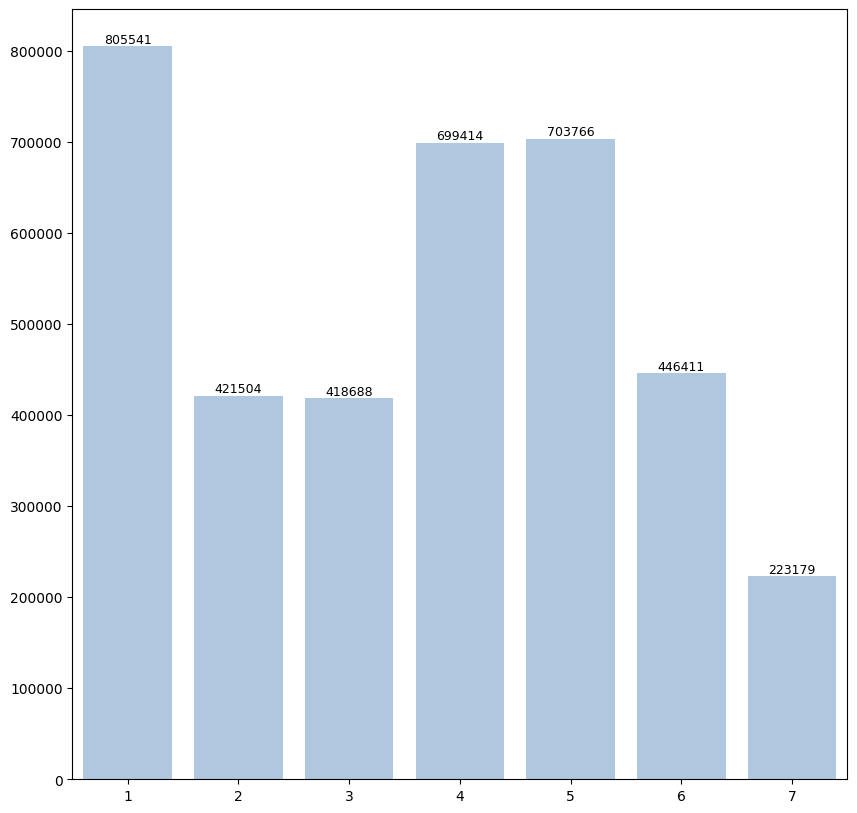

In [207]:
activity_labels = data[:, 12].astype(int)

# Filtrar apenas atividades 1 a 7
mask = (activity_labels >= 1) & (activity_labels <= 7)
data_filtered = data[mask]
filtered_labels = activity_labels[mask]

# Contar exemplos por atividade
atividades, contagens = np.unique(filtered_labels, return_counts=True)

# Plot com seaborn
plt.figure(figsize=(10,10))
grafico = sns.barplot(x=atividades, y=contagens, color='#A7C7E7')
grafico.bar_label(grafico.containers[0], fontsize=9)
plt.show()


## 1.2

In [208]:
def generate_smote_samples(X, y, activity_label, K, k_neighbors=5):

    current_count = np.sum(y == activity_label)
    target_count = current_count + K
    
    smote = SMOTE(
        sampling_strategy={activity_label: target_count},
        k_neighbors=k_neighbors
    )
    
    X_res, y_res = smote.fit_resample(X, y)
    dataset_augmented = np.hstack((X_res, y_res.reshape(-1,1)))
    return dataset_augmented


In [209]:
ignore_cols = [0, 1, 11, 12]
feature_cols = [i for i in range(data.shape[1]) if i not in ignore_cols]

df_norm = data.copy().astype(float)

scaler = StandardScaler()
df_norm[:, feature_cols] = scaler.fit_transform(data[:, feature_cols])

X = df_norm[:, feature_cols]          # apenas sensores
y = data[:, 12].astype(int)           # coluna do label

dataset_augmented = generate_smote_samples(X, y, activity_label=4, K=5)
print("Shape dataset_augmented:", dataset_augmented.shape)

Shape dataset_augmented: (3930878, 10)


## 1.3

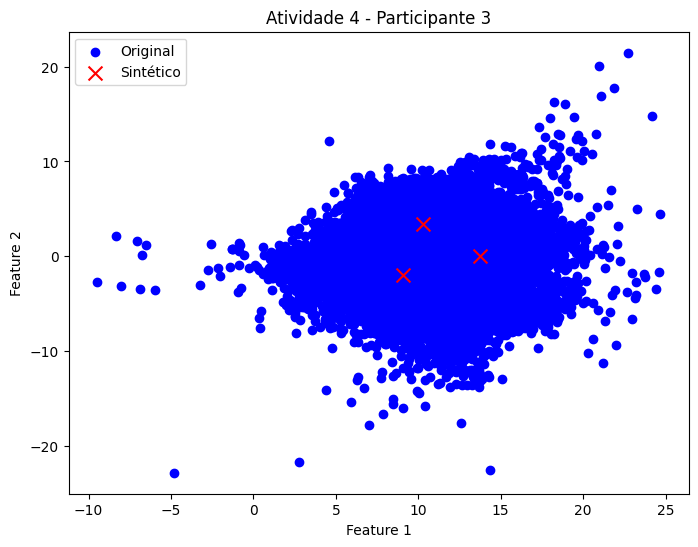

In [210]:
# Filtrar apenas participante 3
participant_id = 3
mask_participant = data[:, 0] == participant_id
data_participant = data[mask_participant]

# Separar features e label
feature_cols = list(range(2, 11))  # sensores
X_part = data_participant[:, feature_cols]
y_part = data_participant[:, 12].astype(int)

# Gerar 3 novas amostras para atividade 4
activity_label = 4
data_augmented = generate_smote_samples(X_part, y_part, activity_label=activity_label, K=3)

# --- 5. Separar exemplos ---
data_activity_original = data_participant[data_participant[:, 12] == activity_label]
num_original = data_activity_original.shape[0]

data_activity_augmented = data_augmented[data_augmented[:, -1] == activity_label]
original_samples = data_activity_augmented[:num_original]
synthetic_samples = data_activity_augmented[num_original:]

# Plotar o pedido
plt.figure(figsize=(8,6))
plt.scatter(original_samples[:, 1], original_samples[:, 2], color='blue', label='Original')
plt.scatter(synthetic_samples[:, 1], synthetic_samples[:, 2], color='red', label='Sintético', marker='x', s=100)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title(f'Atividade {activity_label} - Participante {participant_id}')
plt.legend()
plt.show()


-------------------------------------------------------------------------------

# Exercício 2 - Embedding Features

In [211]:
#codigo do stor do embedding 
def load_model():
  ''' Loads the model from the github repo and obtains just the feature encoder. '''

  repo = 'OxWearables/ssl-wearables'
  # class_num não interessa para extrair features; mas o hub pede este arg
  model = torch.hub.load(repo, 'harnet5', class_num=5, pretrained=True)
  model.eval()

  # Passo crucial: ficar só com a parte auto-supervisionada
  # O README diz que há um 'feature_extractor' (pré-treinado) e um 'classifier' (não treinado). :contentReference[oaicite:14]{index=14}
  feature_encoder = model.feature_extractor
  feature_encoder.to("cpu")
  feature_encoder.eval()

  return feature_encoder


def resample_to_30hz_5s(acc_xyz, fs_in_hz):
    """
    acc_xyz: np.ndarray shape (N, 3) em m/s^2 (ou g), amostrado a fs_in_hz (float)
    devolve:
      acc_resampled: np.ndarray shape (M, 3) já a 30 Hz
      fs_target: 30.0
    """
    fs_target = 30.0
    win_size = 5 # in seconds
    t_in = np.arange(acc_xyz.shape[0]) / fs_in_hz
    t_out = np.arange(0, win_size, 1.0/fs_target)

    acc_resampled = np.zeros((len(t_out), 3), dtype=np.float32)
    for axis in range(3):
        acc_resampled[:, axis] = np.interp(t_out, t_in, acc_xyz[:, axis])

    return acc_resampled, fs_target


def acc_segmentation(data):
  ''' Estract ACC segments and their activities '''

  TIMESTAMP_COL = 10
  MIN_SEGMENT_SIZE = 20
  fs_in_hz = 51.2
  win_size = 5000
  start_time = data[0,TIMESTAMP_COL]
  end_time = start_time + win_size

  activities = []
  segments = []

  while end_time < data[-1,TIMESTAMP_COL]:
    mask = (data[:,TIMESTAMP_COL] >= start_time) & (data[:,TIMESTAMP_COL] < end_time)

    if np.sum(mask) > MIN_SEGMENT_SIZE and np.all(data[mask, -1] == data[mask, -1][0]):

      acc_xyz = data[mask,1:4]
      activity = data[mask, -1][0]
      
      activities.append(activity)
      segments.append( acc_xyz )
      

    start_time = end_time - win_size/2
    end_time = start_time + win_size
  
  
  return segments, activities



# load example file to test embedding
csv_file_path = '../FORTH_TRACE_DATASET/part13/part13dev1.csv'
 
csv_data = np.loadtxt(csv_file_path, delimiter=',')

original_segments, activities = acc_segmentation(csv_data)

resampled_segments = [resample_to_30hz_5s(segment, 51.2)[0] for segment in original_segments]

feature_encoder = load_model()

embeddings_list = []

# reshape segments to [n_segments, dimensions(xyz), time]
x_all = np.transpose( np.array(resampled_segments), (0, 2, 1) )
print(x_all.shape)

# iterate over the resampled segments and pass them 
#    through the model in batches to get the embeddings
batch_size = 5
with torch.no_grad():
    for i in range(0, x_all.shape[0], batch_size):
        xb = torch.from_numpy(x_all[i:i+batch_size]).float().to("cpu")
        eb = feature_encoder(xb)  # (B, D_embed)
        embeddings_list.append(eb.cpu().numpy())

embeddings = np.concatenate(embeddings_list, axis=0)
print(embeddings.shape)

Using cache found in C:\Users\bmsam/.cache\torch\hub\OxWearables_ssl-wearables_main
C:\Users\bmsam/.cache\torch\hub\OxWearables_ssl-wearables_main\hubconf.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues relat

131 Weights loaded
(369, 3, 150)
(369, 512, 1)


In [212]:
embeddings_list = []

base_path = '../FORTH_TRACE_DATASET'

for part_id in range(15):  # participantes de 0 a 14
    part_folder = os.path.join(base_path, f'part{part_id}')
    
    #todos os CSVs da pasta
    csv_files = sorted([f for f in os.listdir(part_folder) if f.endswith('.csv')])
    
    for csv_file in csv_files:
        csv_file_path = os.path.join(part_folder, csv_file)
        csv_data = np.loadtxt(csv_file_path, delimiter=',')
        
        # segmentar
        segments, activities = acc_segmentation(csv_data)
        
        # Filtrar apenas atividades 1 a 7
        segments_filtered = []
        participant_filtered = []
        activities_filtered= []
        for seg, act in zip(segments, activities):
            if 1 <= act <= 7:
                segments_filtered.append(seg)
                participant_filtered.append(part_id) 
                activities_filtered.append(act)

        if len(segments_filtered) == 0:
            continue
        
        # resample para 30Hz
        resampled_segments = [resample_to_30hz_5s(seg, 51.2)[0] for seg in segments_filtered]
        x_all = np.array([seg.T for seg in resampled_segments], dtype=np.float32)
        
        # extrair embeddings
        batch_size = 5
        with torch.no_grad():
            for i in range(0, x_all.shape[0], batch_size):
                xb = torch.from_numpy(x_all[i:i+batch_size]).float().to("cpu")
                eb = feature_encoder(xb)
                eb_np = eb.cpu().numpy()
                
                for j, seg_emb in enumerate(eb_np):
                    embeddings_list.append(
                        np.hstack([
                            participant_filtered[i+j],
                            seg_emb.flatten(),
                            activities_filtered[i+j]
                        ])
                    )

# concatenar todos os participantes
embeddings_dataset = np.array(embeddings_list, dtype=np.float32)  
print(f"Shape final do embeddings_dataset (linhas x features+pid+atividade): {embeddings_dataset.shape}")

# exemplo
for pid in range(15):
    part_mask = embeddings_dataset[:,0] == pid
    part_data = embeddings_dataset[part_mask]
    if part_data.shape[0] == 0:
        continue
    print(f"Participante {pid} -> {part_data.shape[0]} segmentos")
    print("Exemplo de embedding (primeira linha, primeiras 10 dimensões):")
    print(part_data[0,:12]) 
    print("-"*30)

Shape final do embeddings_dataset (linhas x features+pid+atividade): (27699, 514)
Participante 0 -> 1846 segmentos
Exemplo de embedding (primeira linha, primeiras 10 dimensões):
[0.         0.         0.         0.         0.         0.02860497
 0.05294336 0.         0.04316683 0.         0.04375382 0.10662704]
------------------------------
Participante 1 -> 1844 segmentos
Exemplo de embedding (primeira linha, primeiras 10 dimensões):
[1.         0.         0.         0.         0.         0.02128764
 0.03353288 0.         0.04632877 0.         0.03986754 0.08333381]
------------------------------
Participante 2 -> 1847 segmentos
Exemplo de embedding (primeira linha, primeiras 10 dimensões):
[2.         0.         0.         0.         0.         0.01461428
 0.01896847 0.         0.0651965  0.         0.02664905 0.08372725]
------------------------------
Participante 3 -> 1849 segmentos
Exemplo de embedding (primeira linha, primeiras 10 dimensões):
[3.         0.         0.         0.

[participant_id, activity, embedding_1, embedding_2, ..., embedding_512]
como esta o dataset

---------------------------------

# Exercício 3 - Data splitting strategy

### 3.1

duvida: aqui é necessario que todas as atividades aparecam nos 3 conjuntos ou basta os participantes

# Feature Set

In [213]:
def create_windows(data, fs, window_length=5.0, overlap=0.5):
    n_samples_window = int(fs * window_length)
    step = int(n_samples_window * (1 - overlap))
    windows = []

    pessoas = np.unique(data[:, 0])

    for pessoa in pessoas:
        pessoa_data = data[data[:, 0] == pessoa]
        dispositivos = np.unique(pessoa_data[:, 1])

        for dispositivo in dispositivos:
            sub_data = pessoa_data[pessoa_data[:, 1] == dispositivo]
            n_samples = len(sub_data)

            # sliding windows normais
            for start_idx in range(0, n_samples - n_samples_window + 1, step):
                end_idx = start_idx + n_samples_window
                window_data = sub_data[start_idx:end_idx]
                labels = window_data[:, 12]
                if np.all(labels == labels[0]):
                    windows.append(window_data)

            # incluir última janela incompleta
            if n_samples % step != 0:
                start_idx = n_samples - n_samples_window
                if start_idx < 0:
                    start_idx = 0
                window_data = sub_data[start_idx:]
                labels = window_data[:, 12]
                if np.all(labels == labels[0]):
                    windows.append(window_data)

    return windows
windows = create_windows(data, fs=51.2, window_length=5.0, overlap=0.5)
np.save("windows.npy", np.array(windows))

In [214]:
nomes_features = [
    # Person ID na primeira coluna
    'person_id',
    # ax
    'ax_mean','ax_median','ax_std','ax_var','ax_rms','ax_mean_derivative','ax_skewness','ax_kurtosis','ax_iqr','ax_zcr','ax_mcr',
    'ax_SpecEntropy','ax_DominantFreq','ax_Energy',
    # ay
    'ay_mean','ay_median','ay_std','ay_var','ay_rms','ay_mean_derivative','ay_skewness','ay_kurtosis','ay_iqr','ay_zcr','ay_mcr',
    'ay_SpecEntropy','ay_DominantFreq','ay_Energy',
    # az
    'az_mean','az_median','az_std','az_var','az_rms','az_mean_derivative','az_skewness','az_kurtosis','az_iqr','az_zcr','az_mcr',
    'az_SpecEntropy','az_DominantFreq','az_Energy',
    # gx
    'gx_mean','gx_median','gx_std','gx_var','gx_rms','gx_mean_derivative','gx_skewness','gx_kurtosis','gx_iqr','gx_zcr','gx_mcr',
    'gx_SpecEntropy','gx_DominantFreq','gx_Energy',
    # gy
    'gy_mean','gy_median','gy_std','gy_var','gy_rms','gy_mean_derivative','gy_skewness','gy_kurtosis','gy_iqr','gy_zcr','gy_mcr',
    'gy_SpecEntropy','gy_DominantFreq','gy_Energy',
    # gz
    'gz_mean','gz_median','gz_std','gz_var','gz_rms','gz_mean_derivative','gz_skewness','gz_kurtosis','gz_iqr','gz_zcr','gz_mcr',
    'gz_SpecEntropy','gz_DominantFreq','gz_Energy',
    # mx
    'mx_mean','mx_median','mx_std','mx_var','mx_rms','mx_mean_derivative','mx_skewness','mx_kurtosis','mx_iqr','mx_zcr','mx_mcr',
    'mx_SpecEntropy','mx_DominantFreq','mx_Energy',
    # my
    'my_mean','my_median','my_std','my_var','my_rms','my_mean_derivative','my_skewness','my_kurtosis','my_iqr','my_zcr','my_mcr',
    'my_SpecEntropy','my_DominantFreq','my_Energy',
    # mz
    'mz_mean','mz_median','mz_std','mz_var','mz_rms','mz_mean_derivative','mz_skewness','mz_kurtosis','mz_iqr','mz_zcr','mz_mcr',
    'mz_SpecEntropy','mz_DominantFreq','mz_Energy',

    # Features gerais
    'Corr_Acc_XY','Corr_Acc_XZ','Corr_Acc_YZ',
    'Corr_Gyr_XY','Corr_Gyr_XZ','Corr_Gyr_YZ',
    'Corr_Mag_XY','Corr_Mag_XZ','Corr_Mag_YZ',
    'MI_mean','MI_var',
    'SMA',
    'EVA_Acc_1','EVA_Acc_2',
    'Corr_Acc_Gravity_Heading',
    'AvgVelHeading','AvgVelGravity',
    'AvgRotAngleGravity',
    'AvgAccEnergy',
    'AvgRotEnergy',
    # incluir a label no final
    'label']

In [215]:
def calculate_features (windows):
        features = []
        labels= []
        fs= 51.2
        for window in windows:
                window_features = []
                window_label = window[0, 12]
                if window_label <= 7 and window_label >= 1:
                        pers_id = window[0, 0]
                        labels.append(window_label)

                        for col in range(2, 11):
                                coluna = window[:, col]
                                N = len(coluna)
                                mean_col = np.mean(coluna)

                                #temporal features
                                #média
                                window_features.append(mean_col)

                                #mediana
                                window_features.append(np.median(coluna))

                                #desvião padrão
                                window_features.append(np.std(coluna))

                                #variância
                                window_features.append(np.var(coluna))

                                #raíz quadrada da média  
                                window_features.append(np.sqrt(np.mean(coluna**2)))

                                #derivda média
                                window_features.append(np.mean(np.diff(coluna)))

                                #skewness
                                window_features.append(stats.skew(coluna))

                                #Kurtosis
                                window_features.append(stats.kurtosis(coluna)) 

                                #IQR
                                window_features.append(stats.iqr(coluna))

                                #zero crossing rate    
                                window_features.append(len (np.where(np.diff(np.sign(coluna)))[0])/N)

                                #mean corssing rate
                                window_features.append(len (np.where(np.diff(np.sign(coluna - mean_col)))[0])/N)

                                #spectral features ------------
                                fft_col = np.fft.rfft(coluna)
                                fft_energy = np.abs(fft_col)**2
                                fft_freqs = np.fft.rfftfreq(N, 1/fs)

                                #Spectral Entropy 
                                psd = fft_energy[1:]
                                psd_norm = psd / np.sum(psd)
                                spectral_entropy = -np.sum(psd_norm * np.log2(psd_norm + 1e-12))
                                window_features.append(spectral_entropy)

                                # Dominant Frequency
                                dominant_freq = fft_freqs[np.argmax(fft_energy)]
                                window_features.append(dominant_freq)

                                #Energy
                                energy = np.sum(psd) / N
                                window_features.append(energy)

                        #pairwise correlation----------
                        # Accelerometer correlations
                        acc = window[:, 2:5]
                        corr_acc = np.corrcoef(acc.T)[np.triu_indices(3, 1)]
                        window_features.extend(corr_acc)
                        # Gyroscope correlations
                        gyr = window[:, 5:8]
                        corr_gyr = np.corrcoef(gyr.T)[np.triu_indices(3, 1)]
                        window_features.extend(corr_gyr)
                        # Magnetometer correlations
                        mag = window[:, 8:11]
                        corr_mag = np.corrcoef(mag.T)[np.triu_indices(3, 1)]
                        window_features.extend(corr_mag)

                        #Movement intensity --> temporal
                        ax, ay, az = window[:, 2], window[:, 3], window[:, 4]
                        mi = np.sqrt(np.mean(ax**2) + np.mean(ay**2) + np.mean(az**2))
                        window_features.extend([np.mean(mi), np.var(mi)])

                        #normalized signal magnitude area (SMA) --> temporal
                        T = len(ax)
                        sma = (np.sum(np.abs(ax)) + np.sum(np.abs(ay)) + np.sum(np.abs(az))) / T
                        window_features.append(sma)

                        # EVA --> temporal
                        eva_acc = np.sort(np.linalg.eigvals(np.cov(window[:, 2:5] - np.mean(window[:, 2:5], axis=0), rowvar=False)))[::-1][:2]
                        window_features.extend(eva_acc)

                        # Correlation between Acceleration along Gravity and Heading Directions --> temporal
                        a_heading = np.sqrt(ay**2 + az**2)
                        window_features.append(np.corrcoef(ax, a_heading)[0, 1])

                        # Averaged Velocity along Gravity Direction --> temporal
                        t = window[:, 11]
                        vy = cumulative_trapezoid(ay, t, initial=0)
                        vz = cumulative_trapezoid(az, t, initial=0)
                        vx = cumulative_trapezoid(ax, t, initial=0)
                        avh = np.sqrt(np.mean(vy)**2 + np.mean(vz)**2)
                        avg = np.mean(vx)
                        window_features.extend([avh, avg])

                        # Averaged Rotation Angle along Gravity Direction --> temporal
                        gx = window[:, 5]
                        theta_x = cumulative_trapezoid(gx, t, initial=0)
                        window_features.append(np.mean(theta_x))

                        # Averaged Acceleration Energy --> spectral
                        acc_block = window[:, 2:5]  # ax, ay, az
                        fft_acc = np.fft.rfft(acc_block, axis=0)
                        energy_acc = np.sum((np.abs(fft_acc)**2)[1:, :], axis=0) / acc_block.shape[0]
                        AEE = np.mean(energy_acc)
                        window_features.append(AEE)

                        # Averaged Rotation Energy --> spectral
                        gyr_block = window[:, 5:8]  # gx, gy, gz
                        fft_gyr = np.fft.rfft(gyr_block, axis=0)
                        energy_gyr = np.sum((np.abs(fft_gyr)**2)[1:, :], axis=0) / gyr_block.shape[0]
                        ARE = np.mean(energy_gyr)
                        window_features.append(ARE)

                        features.append([pers_id] + window_features)
        feature_set_with_labels = np.column_stack((features, labels)) 
        return feature_set_with_labels
#feature_set = calculate_features(windows)

In [216]:
#features = pd.DataFrame(feature_set, columns=nomes_features)
#features.to_csv('features_dataset.csv', header=nomes_features, index=False)
feature_dataset = pd.read_csv('features_dataset.csv').to_numpy()

participants_data = {}
for part_id in range(15):
    part_rows = feature_dataset[feature_dataset[:, 0] == part_id]
    if len(part_rows) > 0:
        participants_data[part_id] = part_rows

for pid, pdata in participants_data.items():
    print(f"Participante {pid} -> {pdata.shape[0]} linhas")

Participante 0 -> 1888 linhas
Participante 1 -> 1882 linhas
Participante 2 -> 1895 linhas
Participante 3 -> 1892 linhas
Participante 4 -> 1754 linhas
Participante 5 -> 1873 linhas
Participante 6 -> 1904 linhas
Participante 7 -> 1864 linhas
Participante 8 -> 1807 linhas
Participante 9 -> 1847 linhas
Participante 10 -> 1853 linhas
Participante 11 -> 1780 linhas
Participante 12 -> 1888 linhas
Participante 13 -> 1898 linhas
Participante 14 -> 1893 linhas


In [217]:
# features
features_train_list = []
features_val_list = []
features_test_list = []
def split_features_dataset(feature_dataset,random_state):
    train_list, val_list, test_list = [], [], []
    for part_id in range(15):
        part_rows = feature_dataset[feature_dataset[:, 0] == part_id]
        if len(part_rows) == 0:
            continue
            
        train, temp = train_test_split(part_rows, test_size=0.4, random_state=random_state, shuffle=True)
        val, test = train_test_split(temp, test_size=0.5, random_state=random_state, shuffle=True)
        
        train_list.append(train)
        val_list.append(val)
        test_list.append(test)
    
    features_train = np.vstack(train_list)
    features_val = np.vstack(val_list)
    features_test = np.vstack(test_list)
    
    return features_train, features_val, features_test

features_train, features_val, features_test = split_features_dataset(feature_dataset,42)

print("FEATURES TRAIN:", features_train.shape)
print("FEATURES VAL:", features_val.shape)
print("FEATURES TEST:", features_test.shape)
def split_embeddings_dataset(embeddings_dataset, random_state):
    train_list, val_list, test_list = [], [], []
    
    for pid in range(15):
        part_mask = embeddings_dataset[:, 0] == pid
        part_data = embeddings_dataset[part_mask]
        
        if len(part_data) == 0:
            continue
            
        train, temp = train_test_split(part_data, test_size=0.4, random_state=random_state, shuffle=True)
        val, test = train_test_split(temp, test_size=0.5, random_state=random_state, shuffle=True)
        
        train_list.append(train)
        val_list.append(val)
        test_list.append(test)
    
    emb_train = np.concatenate(train_list, axis=0)
    emb_val = np.concatenate(val_list, axis=0)
    emb_test = np.concatenate(test_list, axis=0)
    
    return emb_train, emb_val, emb_test

emb_train, emb_val, emb_test = split_embeddings_dataset(embeddings_dataset,42)

print("EMBEDDINGS TRAIN:", emb_train.shape)
print("EMBEDDINGS VAL:", emb_val.shape)
print("EMBEDDINGS TEST:", emb_test.shape)

FEATURES TRAIN: (16744, 148)
FEATURES VAL: (5585, 148)
FEATURES TEST: (5589, 148)
EMBEDDINGS TRAIN: (16613, 514)
EMBEDDINGS VAL: (5539, 514)
EMBEDDINGS TEST: (5547, 514)


### 3.2

In [218]:
all_participants = np.arange(15)
def split_9_3_3 (seed):
    np.random.seed(seed)
    shuffled = np.random.permutation(all_participants)
    train_participants = shuffled[:9]
    val_participants   = shuffled[9:12]
    test_participants  = shuffled[12:]

    return train_participants, val_participants, test_participants

train_participants, val_participants, test_participants = split_9_3_3(seed=42)

def filter_by_participants(dataset, participants):
    mask = np.isin(dataset[:, 0], participants)
    return dataset[mask]

# feature
features_train_subj = filter_by_participants(feature_dataset, train_participants)
features_val_subj   = filter_by_participants(feature_dataset, val_participants)
features_test_subj  = filter_by_participants(feature_dataset, test_participants)

print("FEATURES TRAIN:", features_train_subj.shape)
print("FEATURES VAL  :", features_val_subj.shape)
print("FEATURES TEST :", features_test_subj.shape)

#embeddings
emb_train_subj = filter_by_participants(embeddings_dataset, train_participants)
emb_val_subj   = filter_by_participants(embeddings_dataset, val_participants)
emb_test_subj  = filter_by_participants(embeddings_dataset, test_participants)

print("\n------")
print("EMBEDDINGS TRAIN:", emb_train_subj.shape)
print("EMBEDDINGS VAL  :", emb_val_subj.shape)
print("EMBEDDINGS TEST :", emb_test_subj.shape)

FEATURES TRAIN: (16763, 148)
FEATURES VAL  : (5471, 148)
FEATURES TEST : (5684, 148)

------
EMBEDDINGS TRAIN: (16545, 514)
EMBEDDINGS VAL  : (5565, 514)
EMBEDDINGS TEST : (5589, 514)


*features_dataset*
as colunas representam : 
- coluna 0: ID do participante
- Coluna 1: device ID 
- coluna 2 a 11: valores das features
- coluna 12: timestamp
- coluna 13: label da atividade


*embeddings_dataset*
- Coluna 0: participant_id
- Coluna 1 a 512: embeddings (512 dimensões)
- Coluna 513: activity(label)

### 3.3

No 3.1 cada participante contribui com dados de treino, validação e teste.
- Ou seja, cada participante está dividido em dados de treino, validação e teste. 
- Isto pode fazer com que o modelo aprenda padrões individuais daquele participante  

No 3.2 cada participante só está num dos conjuntos de dados: ou no de teste, ou de treino ou de validação.
- O modelo aqui não conhece padrões especificos de cada participante e por isso se calhar esta estratégia é mais realista



A melhor estratégia para ser aplicada aos novos participantes é então a 2º porque o modelo ainda não viu dados do mesmo individuo e consegue generalizar para novos participantes.

### 3.4. 
Prepare your pipeline in a way that, after the split, for each dataset, you can compute and transform each set into three different scenarios:

a) All features/embeddings dataset

b) PCA-reduced features/embeddings dataset (keeping just the components
that explain 90% of the variance)

c) Feature-selected features/embeddings (keeping just the top 15 features
selected by the ReliefF method).

#### a) All features/embeddings dataset

#### Separação TVT (60/20/20)

In [219]:
# --- Features ---
scaler_feat = StandardScaler()
X_feat_train_all = scaler_feat.fit_transform(features_train[:, 1:-1])
y_feat_train_all = features_train[:, -1].astype(int)
X_feat_val_all = scaler_feat.transform(features_val[:, 1:-1])
y_feat_val_all = features_val[:, -1].astype(int)
X_feat_test_all = scaler_feat.transform(features_test[:, 1:-1])
y_feat_test_all = features_test[:, -1].astype(int)

# --- Embeddings ---
scaler_emb = StandardScaler()
X_emb_train_all = scaler_emb.fit_transform(emb_train[:, 1:-1])
y_emb_train_all = emb_train[:, -1].astype(int)
X_emb_val_all = scaler_emb.transform(emb_val[:, 1:-1])
y_emb_val_all = emb_val[:, -1].astype(int)
X_emb_test_all = scaler_emb.transform(emb_test[:, 1:-1])
y_emb_test_all = emb_test[:, -1].astype(int)

#### Separação por Subject (9/3/3)

In [220]:
# --- Features ---
scaler_feat_subj = StandardScaler()
X_feat_train_subj = scaler_feat_subj.fit_transform(features_train_subj[:, 1:-1])
y_feat_train_subj = features_train_subj[:, -1].astype(int)
y_feat_val_subj = features_val_subj[:, -1].astype(int)
X_feat_val_subj = scaler_feat_subj.transform(features_val_subj[:, 1:-1])
X_feat_test_subj = scaler_feat_subj.transform(features_test_subj[:, 1:-1])
y_feat_test_subj = features_test_subj[:, -1].astype(int)

# --- Embeddings ---
scaler_emb_subj = StandardScaler()
X_emb_train_subj = scaler_emb_subj.fit_transform(emb_train_subj[:, 1:-1])
y_emb_train_subj = emb_train_subj[:, -1].astype(int)
X_emb_val_subj = scaler_emb_subj.transform(emb_val_subj[:, 1:-1])
y_emb_val_subj = emb_val_subj[:, -1].astype(int)
X_emb_test_subj = scaler_emb_subj.transform(emb_test_subj[:, 1:-1])
y_emb_test_subj = emb_test_subj[:, -1].astype(int)

#### b) PCA-reduced features/embeddings dataset (keeping just the components that explain 90% of the variance)

In [221]:
def apply_pca(X_train, X_val, X_test, variance_threshold=0.90):
    # aplicar o pca
    pca = PCA(n_components=variance_threshold, svd_solver='full')
    X_train_pca = pca.fit_transform(X_train)
    X_val_pca = pca.transform(X_val)
    X_test_pca = pca.transform(X_test)
    
    print(f"PCA - Número de componentes mantidos: {pca.n_components_}")
    return X_train_pca, X_val_pca, X_test_pca

#### Separação TVT (60/20/20)

In [222]:
# Features
X_feat_train_pca, X_feat_val_pca, X_feat_test_pca = apply_pca(
    X_feat_train_all, X_feat_val_all, X_feat_test_all
)
# Embeddings
X_emb_train_pca, X_emb_val_pca, X_emb_test_pca = apply_pca(
    X_emb_train_all, X_emb_val_all, X_emb_test_all
)
# Mostrar shapes PCA para confirmar
#print("FEATURES TRAIN PCA w 602020:", X_feat_train_pca.shape)
#print("EMBEDDINGS TRAIN PCA w 602020:", X_emb_train_pca.shape)

PCA - Número de componentes mantidos: 53
PCA - Número de componentes mantidos: 11


#### Separação por Subject (9/3/3)

In [223]:
# Features
X_feat_train_subj_pca, X_feat_val_subj_pca, X_feat_test_subj_pca = apply_pca(
    X_feat_train_subj, X_feat_val_subj, X_feat_test_subj
)
# Embeddings
X_emb_train_subj_pca, X_emb_val_subj_pca, X_emb_test_subj_pca = apply_pca(
    X_emb_train_subj, X_emb_val_subj, X_emb_test_subj
)

# Mostrar shapes PCA
#print("FEATURES TRAIN PCA w subj:", X_feat_train_subj_pca.shape)
#print("EMBEDDINGS TRAIN PCA w subj:", X_emb_train_subj_pca.shape)

PCA - Número de componentes mantidos: 51
PCA - Número de componentes mantidos: 11


#### c) Feature-selected features/embeddings (keeping just the top 15 features selected by the ReliefF method).

In [253]:
# Versão que utiliza CPU é lenta. Para facilitar foi feita uma versão com o torch
def Relief_with_cpu(X, y, n_features_to_select=15, n_neighbors=100):
    for n in [10, 50, 100]:
        relief = ReliefF(n_features_to_select=n_features_to_select, n_neighbors=n_neighbors)
        relief.fit(X, y)
        top_indices = relief.top_features_[:n_features_to_select]
    return top_indices, relief.feature_importances_

class ReliefF_GPU:
    def __init__(self, n_features_to_select=15, n_neighbors=100):
        self.n_features_to_select = n_features_to_select
        self.k = n_neighbors
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        #print(f"ReliefF a correr em: {self.device}")

    def fit(self, X, y):
        # Enviar dados para a gráfica (caso o cuda esteja disponível)
        X_torch = torch.tensor(X, dtype=torch.float32).to(self.device)
        y_torch = torch.tensor(y, dtype=torch.long).to(self.device)

        # N = número de amostras, F = número de features
        N, F = X_torch.shape
        
        # Verificar a P(C)
        # Isto é feito para ponderar a influência dos vizinhos de outras classes
        # ou seja, um miss numa classe mais comum tem mais peso que uma classe rara.
        
        # Ver o número de atividades e quantas vezes aparecem no y_train.
        classes, counts = torch.unique(y_torch, return_counts=True)
        # Dividir pelo total de amostas para obter a frequencia de cada classe
        priors = counts.float() / N
        # Guardar a info
        class_priors = {c.item(): p.item() for c, p in zip(classes, priors)}
        
        # 2. Matriz de Distâncias (NxN)
        # Para verificar os vizinhos de cada ponto
        dists = torch.cdist(X_torch, X_torch)
        # Para evitar que o próprio ponto seja considerado vizinho, float('inf') é meter a infinito
        dists.fill_diagonal_(float('inf'))
        
        # 3. HITS (Vizinhos da mesma classe)
        # mask_hit[i,j] é True se i e j forem da mesma classe
        mask_hit = (y_torch.view(-1, 1) == y_torch.view(1, -1))
        
        # Isolar vizinhos da mesma classe
        dists_hit = dists.clone()
        dists_hit[~mask_hit] = float('inf') 
        
        # k vizinhos mais próximos da mesma classe
        _, idx_hits = dists_hit.topk(self.k, dim=1, largest=False)
        
        # Diferenças para os Hits: soma das diferenças para os k vizinhos
        # Shape final: (N, F)
        diffs_hits = torch.abs(X_torch.unsqueeze(1) - X_torch[idx_hits]).sum(dim=1)
        
        # 4. MISSES (Classes diferentes)
        # Inicializar com shape (N, F) para manter os scores por amostra
        total_miss_diffs = torch.zeros(N, F, device=self.device)
        
        # P(class(Ri)) para cada amostra i. Shape (N, 1)
        p_y_lookup = torch.zeros(int(classes.max()) + 1, device=self.device)
        for c, p in class_priors.items():
            p_y_lookup[c] = p
        p_y = p_y_lookup[y_torch].view(-1, 1)
        
        for c in classes:
            c = c.item()
            
            # Encontrar os pontos da classe c
            # Shape: (1, N)
            mask_col_c = (y_torch == c).view(1, -1)
            
            # Isolar vizinhos da classe c
            dists_c = dists.clone()
            dists_c[:, ~mask_col_c.squeeze()] = float('inf') 
            
            # guardar os indices dos menores valores (k vizinhos mais próximos da classe c)
            _, idx_miss_c = dists_c.topk(self.k, dim=1, largest=False)
            
            # Diferenças para os vizinhos da classe c
            # Shape: (N, F)
            diffs_miss_c = torch.abs(X_torch.unsqueeze(1) - X_torch[idx_miss_c]).sum(dim=1)
            
            # Peso de ponderação: P(C) / (1 - P(class(Ri)))
            weight_factor = class_priors[c] / (1.0 - p_y + 1e-8)
            
            # Amostras que não são da classe c
            # Shape: (N, 1)
            mask_not_c = (y_torch != c).view(-1, 1)

            # Só adicionamos se a amostra i NÃO for da classe c (ou seja, miss)
            total_miss_diffs += diffs_miss_c * weight_factor * mask_not_c.float()

        # 5. Scores Finais
        # W = Misses - Hits
        scores = total_miss_diffs - diffs_hits

        # Média sobre todas as amostras
        feature_scores = scores.mean(dim=0)
        
        # Guardar e Ordenar
        self.feature_importances_ = feature_scores.cpu().numpy()
        
        # Ordenar decrescente (maior score é melhor)
        self.top_features_ = np.argsort(self.feature_importances_)[::-1][:self.n_features_to_select]
        
        return self.top_features_

#### Função para aplicar ReliefF
Esta função vai executar o método ReliefF e retornar os dados necessários assim como os indices das features.

(Após serem feitos testes o melhor k foi 5, com um f1_score de 0.6 de média)

In [266]:
def apply_relieff_pipeline(X_train, y_train, X_val, X_test, n_features_select=15):
    """Aplica ReliefF: calcula no train, aplica em todos"""
   
    selector = ReliefF_GPU(n_features_to_select=n_features_select, n_neighbors=5)
    selected_indices = selector.fit(X_train, y_train)

    X_train_relief = X_train[:, selected_indices]
    X_val_relief = X_val[:, selected_indices]
    X_test_relief = X_test[:, selected_indices]
        
    print(f"ReliefF - Top {n_features_select} features selecionadas")
    return X_train_relief, X_val_relief, X_test_relief, selected_indices


#### Separação TVT

In [267]:
X_feat_train_relief, X_feat_val_relief, X_feat_test_relief, feat_indices = apply_relieff_pipeline(
    X_feat_train_all, y_feat_train_all, X_feat_val_all, X_feat_test_all
)
X_emb_train_relief, X_emb_val_relief, X_emb_test_relief, emb_indices = apply_relieff_pipeline(
    X_emb_train_all, y_emb_train_all, X_emb_val_all,  X_emb_test_all
)

ReliefF - Top 15 features selecionadas
ReliefF - Top 15 features selecionadas


#### Separação por Subject (9/3/3)

In [268]:
X_feat_train_subj_relief, X_feat_val_subj_relief, X_feat_test_subj_relief, feat_indices_subj = apply_relieff_pipeline(
    X_feat_train_subj, y_feat_train_subj, X_feat_val_subj, X_feat_test_subj
)
X_emb_train_subj_relief, X_emb_val_subj_relief, X_emb_test_subj_relief, emb_indices_subj = apply_relieff_pipeline(
    X_emb_train_subj, y_emb_train_subj, X_emb_val_subj, X_emb_test_subj)

ReliefF - Top 15 features selecionadas
ReliefF - Top 15 features selecionadas


-------------------------------------------------------------------------------

## 4 - Model learning
We will now train a model to automatically classify the activity of each segment. We will use k-Nearest Neighbors.

### 4.1
Implement a k-Nearest Neighbors classifier (we expect you to implement your own version, but then you can use the sci-kit learn version if you need better performance. See information in [sklearn_KNN](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)).

#### Implementação KNN (CPU)
Implementação básica que utiliza numpy.

Como funciona:
1. Fit: Os dados de treino (X, y) são guardados em memória;
2. Predict: Para cada ponto de teste é calculada a distância euclidiana até ao ponto de treino;
3. Os indices são ordenados para se selecionar os k vizinhos mais próximos;
4. A classe mais frequente desses k vizinhos é escolhida.

In [229]:
class KNNClassifier:
    def __init__(self, k=5):
        self.k = k
        self.X_train = None
        self.y_train = None
    
    def fit(self, X, y):
        self.X_train = np.array(X)
        self.y_train = np.array(y)
        if len(self.X_train) != len(self.y_train):
            raise ValueError("O Número de amostras em X e y têm de ser igual.")
        
    def _euclidean_distance(self, a, b):
        return np.sqrt(np.sum((a - b) ** 2))
    
    def predict(self, X):
        X_test = np.array(X)
        predictions = []

        for test_point in X_test:
            # Calcukar distâncias para todos os pontos de treino
            distances = np.linalg.norm(self.X_train - test_point, axis=1)
            # Obter os índices dos k vizinhos mais próximos
            k_indices = np.argsort(distances)[:self.k]
            # Obter as labels dos k vizinhos
            k_nearest_labels = self.y_train[k_indices]
            # Por maioria
            most_common = np.bincount(k_nearest_labels.astype(int)).argmax()
            predictions.append(most_common)

        return np.array(predictions)

#### Implementação KNN (GPU)
Para acelerar a executar do KNN, foi implementada uma versão que utiliza o pytorch com CUDA (GPU). É verificado se o cuda está instalado caso contrário é utilizada a CPU.

Como funciona:
1. Os dados são convertidos para tensores e enviados para a GPU/CPU;

2. É utilizada a função cdist para calcular a matriz de distancias euclidianas;

3. Depois são obtidos os indices dos k mais próximos e as respetivas labels;

4. A função evaluate permite testar múltiplos k. As distâncias são calculadas apenas 1 vez (utilizando logo o maior k que vai incluir todos os outros).



In [269]:
class KNNClassifierGPU:
    def __init__(self, k=5):
        self.k = k
        self.X_train = None
        self.y_train = None
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f"KNN está a correr com: {self.device}")

    def fit(self, X, y):
        # Converte os dados para tensores e envia para a GPU
        self.X_train = torch.tensor(X, dtype=torch.float32).to(self.device)
        self.y_train = torch.tensor(y, dtype=torch.long).to(self.device)

        if len(self.X_train) != len(self.y_train):
            raise ValueError("O Número de amostras em X e y tem de ser igual.")
    
    def _get_neighbor_labels(self, X, k):
        # Receber os dados novos
        X_gpu = torch.tensor(X, dtype=torch.float32).to(self.device)
        
        # Matriz de distâncias
        dists = torch.cdist(X_gpu, self.X_train, p=2)
        
        # Indices dos k mais próximos
        _, knn_indices = dists.topk(k, largest=False, dim=1)
        
        # Labels correspondentes
        return self.y_train[knn_indices]

    def predict(self, X):
        neighbor_labels = self._get_neighbor_labels(X, self.k)

        # Aprovar por maioria
        # o torch.mode retorna o valor mais frequente em cada linha
        # (values, indices) = torch.mode(...)
        predictions, _ = torch.mode(neighbor_labels, dim=1)
        return predictions.cpu().numpy()
    
    def evaluate_k_values(self, X_val, y_val, k_values):
        max_k = max(k_values)

        # Calcular vizinhos para o maior k
        all_nearest_labels = self._get_neighbor_labels(X_val, max_k)

        results = []
        best_k = k_values[0]
        best_f1 = -1.0

        for k in k_values:
            # Pegamos apenas nas primeiras k colunas da matriz
            current_k_labels = all_nearest_labels[:, :k]
            
            y_pred_gpu, _ = torch.mode(current_k_labels, dim=1)
            y_pred = y_pred_gpu.cpu().numpy()
            
            # Métricas
            acc = metrics.accuracy_score(y_val, y_pred)
            f1_macro = metrics.f1_score(y_val, y_pred, average='macro')
            f1_weighted = metrics.f1_score(y_val, y_pred, average='weighted')
            
            results.append({
                'k': k,
                'accuracy': acc,
                'f1_macro': f1_macro,
                'f1_weighted': f1_weighted
            })
            
            if f1_macro > best_f1:
                best_f1 = f1_macro
                best_k = k
                
        return best_k, best_f1, results

# Usar
#gpu_knn = KNNClassifierGPU(k=k)
#gpu_knn.fit(X_train, y_train)
#y_pred = gpu_knn.predict(X_test)

### 4.2
Create a function that receives two lists of values: the true labels and predicted labels, and returns a set of classification metrics: confusion matrix, accuracy, f1 score, precision, recall, etc.

In [270]:
def evaluate_model(labels_set, y_pred):
    print(metrics.classification_report(labels_set, y_pred))
    print(metrics.confusion_matrix(labels_set, y_pred))

-------------------------------------------------------------------------------

## 5 - Model evaluation
For each splitting strategy (2) applied for the 3 versions (all feats, PCA feats, ReliefF feats) of the 2 datasets (features, embeddings), train the classifier and evaluate its results:

### 5.1 Hyperparameter tuning
Select the best value of k using only the train and validation data. Then, with the best k, retrain with the dataset (train + validation) and evaluate on the test set.

### Função para testar diversos K

In [ ]:
def find_best_k(X_train, y_train, X_val, y_val, k_values=[3, 5, 7, 9, 11, 15, 17, 19, 21]):
    knn_opt = KNNClassifierGPU()
    
    # Carregar os dados de treino
    knn_opt.fit(X_train, y_train)
    
    # Avaliar os diferentes k
    best_k, best_f1, results = knn_opt.evaluate_k_values(X_val, y_val, k_values)
    
    return best_k, best_f1, results

### Função para testar a pipeline completa

In [273]:
def full_evaluation_pipeline(X_train, y_train, X_val, y_val, X_test, y_test, name=""):
    """Pipeline completo: tuning + re-treino + avaliação final com múltiplas métricas"""
    
    # 1. Encontrar o melhor k
    best_k, val_f1, results = find_best_k(X_train, y_train, X_val, y_val)
    print(f"\n{'='*50}")
    print(f"[{name}]")
    print(f"Melhor k: {best_k} (F1 macro validação: {val_f1:.4f})")
    
    # 2. Re-treinar com train + validation
    X_train_full = np.vstack([X_train, X_val])
    y_train_full = np.concatenate([y_train, y_val])
    
    knn_final = KNNClassifierGPU(k=best_k)
    knn_final.fit(X_train_full, y_train_full)
    
    # 3. Avaliar no X_test
    y_pred_test = knn_final.predict(X_test)
    
    test_acc = metrics.accuracy_score(y_test, y_pred_test)
    test_f1_macro = metrics.f1_score(y_test, y_pred_test, average='macro')
    test_f1_weighted = metrics.f1_score(y_test, y_pred_test, average='weighted')
    test_precision = metrics.precision_score(y_test, y_pred_test, average='macro')
    test_recall = metrics.recall_score(y_test, y_pred_test, average='macro')
    
    print(f"\n--- Métricas no TEST ---")
    print(f"Accuracy:     {test_acc:.4f}")
    print(f"F1 Macro:     {test_f1_macro:.4f}")
    print(f"F1 Weighted:  {test_f1_weighted:.4f}")
    print(f"Precision:    {test_precision:.4f}")
    print(f"Recall:       {test_recall:.4f}")
    
    print(f"\nClassification Report:")
    print(metrics.classification_report(y_test, y_pred_test))
    print(f"Confusion Matrix:")
    print(metrics.confusion_matrix(y_test, y_pred_test))
    
    return {
        'name': name,
        'best_k': best_k,
        'val_f1': val_f1,
        'test_acc': test_acc,
        'test_f1_macro': test_f1_macro,
        'test_f1_weighted': test_f1_weighted,
        'test_precision': test_precision,
        'test_recall': test_recall,
        'y_pred': y_pred_test,
        'y_true': y_test,
        'k_results': results
    }

In [ ]:
all_results = []

# ==================== SPLIT 3.1 (60-20-20) ====================
print("\n" + "="*60)
print("SPLIT 3.1 - 60-20-20")
print("="*60)

# Features
all_results.append(full_evaluation_pipeline(
    X_feat_train_all, y_feat_train_all, X_feat_val_all, y_feat_val_all, X_feat_test_all, y_feat_test_all,
    name="3.1 Features - All"
))
all_results.append(full_evaluation_pipeline(
    X_feat_train_pca, y_feat_train_all, X_feat_val_pca, y_feat_val_all, X_feat_test_pca, y_feat_test_all,
    name="3.1 Features - PCA"
))
all_results.append(full_evaluation_pipeline(
    X_feat_train_relief, y_feat_train_all, X_feat_val_relief, y_feat_val_all, X_feat_test_relief, y_feat_test_all,
    name="3.1 Features - ReliefF"
))

# Embeddings
all_results.append(full_evaluation_pipeline(
    X_emb_train_all, y_emb_train_all, X_emb_val_all, y_emb_val_all, X_emb_test_all, y_emb_test_all,
    name="3.1 Embeddings - All"
))
all_results.append(full_evaluation_pipeline(
    X_emb_train_pca, y_emb_train_all, X_emb_val_pca, y_emb_val_all, X_emb_test_pca, y_emb_test_all,
    name="3.1 Embeddings - PCA"
))
all_results.append(full_evaluation_pipeline(
    X_emb_train_relief, y_emb_train_all, X_emb_val_relief, y_emb_val_all, X_emb_test_relief, y_emb_test_all,
    name="3.1 Embeddings - ReliefF"
))

# ==================== SPLIT 3.2 (por subject) ====================
print("\n" + "="*60)
print("SPLIT 3.2 - Por Subject (9-3-3)")
print("="*60)

# Features - USAR DADOS NORMALIZADOS
all_results.append(full_evaluation_pipeline(
    X_feat_train_subj, y_feat_train_subj, X_feat_val_subj, y_feat_val_subj, X_feat_test_subj, y_feat_test_subj,
    name="3.2 Features - All"
))
all_results.append(full_evaluation_pipeline(
    X_feat_train_subj_pca, y_feat_train_subj, X_feat_val_subj_pca, y_feat_val_subj, X_feat_test_subj_pca, y_feat_test_subj,
    name="3.2 Features - PCA"
))
all_results.append(full_evaluation_pipeline(
    X_feat_train_subj_relief, y_feat_train_subj, X_feat_val_subj_relief, y_feat_val_subj, X_feat_test_subj_relief, y_feat_test_subj,
    name="3.2 Features - ReliefF"
))

# Embeddings
all_results.append(full_evaluation_pipeline(
    X_emb_train_subj, y_emb_train_subj, X_emb_val_subj, y_emb_val_subj, X_emb_test_subj, y_emb_test_subj,
    name="3.2 Embeddings - All"
))
all_results.append(full_evaluation_pipeline(
    X_emb_train_subj_pca, y_emb_train_subj, X_emb_val_subj_pca, y_emb_val_subj, X_emb_test_subj_pca, y_emb_test_subj,
    name="3.2 Embeddings - PCA"
))
all_results.append(full_evaluation_pipeline(
    X_emb_train_subj_relief, y_emb_train_subj, X_emb_val_subj_relief, y_emb_val_subj, X_emb_test_subj_relief, y_emb_test_subj,
    name="3.2 Embeddings - ReliefF"
))


SPLIT 3.1 - 60-20-20 (NORMALIZADO)
KNN está a correr com: cuda

[3.1 Features - All]
Melhor k: 3 (F1 macro validação: 0.7431)
KNN está a correr com: cuda

--- Métricas no TEST ---
Accuracy:     0.7794
F1 Macro:     0.7513
F1 Weighted:  0.7748
Precision:    0.7593
Recall:       0.7511

Classification Report:
              precision    recall  f1-score   support

           1       0.95      0.98      0.97      1149
           2       0.94      0.93      0.93       658
           3       0.95      0.93      0.94       642
           4       0.60      0.66      0.63       996
           5       0.68      0.62      0.65      1150
           6       0.71      0.81      0.76       654
           7       0.49      0.31      0.38       340

    accuracy                           0.78      5589
   macro avg       0.76      0.75      0.75      5589
weighted avg       0.77      0.78      0.77      5589

Confusion Matrix:
[[1130    7    7    3    2    0    0]
 [  19  613   26    0    0    0    0]

In [276]:
print("\n" + "="*90)
print("RESUMO DE RESULTADOS")
print("="*90)
print(f"{'Modelo':<30} {'k':<4} {'Acc':<8} {'F1 Macro':<10} {'F1 Weight':<10} {'Precision':<10} {'Recall':<8}")
print("-"*90)
for r in all_results:
    print(f"{r['name']:<30} {r['best_k']:<4} {r['test_acc']:<8.4f} {r['test_f1_macro']:<10.4f} {r['test_f1_weighted']:<10.4f} {r['test_precision']:<10.4f} {r['test_recall']:<8.4f}")


RESUMO DE RESULTADOS
Modelo                         k    Acc      F1 Macro   F1 Weight  Precision  Recall  
------------------------------------------------------------------------------------------
3.1 Features - All             3    0.7794   0.7513     0.7748     0.7593     0.7511  
3.1 Features - PCA             3    0.7615   0.7293     0.7557     0.7378     0.7307  
3.1 Features - ReliefF         3    0.7728   0.7387     0.7680     0.7453     0.7389  
3.1 Embeddings - All           5    0.7089   0.6639     0.7030     0.6766     0.6632  
3.1 Embeddings - PCA           5    0.6407   0.5893     0.6335     0.5952     0.5913  
3.1 Embeddings - ReliefF       7    0.6207   0.5503     0.6068     0.6021     0.5647  
3.2 Features - All             5    0.6429   0.5945     0.6319     0.6046     0.5977  
3.2 Features - PCA             9    0.6532   0.5950     0.6381     0.6118     0.6018  
3.2 Features - ReliefF         9    0.6091   0.5603     0.6043     0.5680     0.5628  
3.2 Embeddings - 

### 5.2 Report and analyse results
Check the confusion matrices and observe which activities are harder to classify. Which dataset worked best (features vs embeddings)? Did feature selection improve the performance? Etc.


5.2 - ANÁLISE DAS MATRIZES DE CONFUSÃO


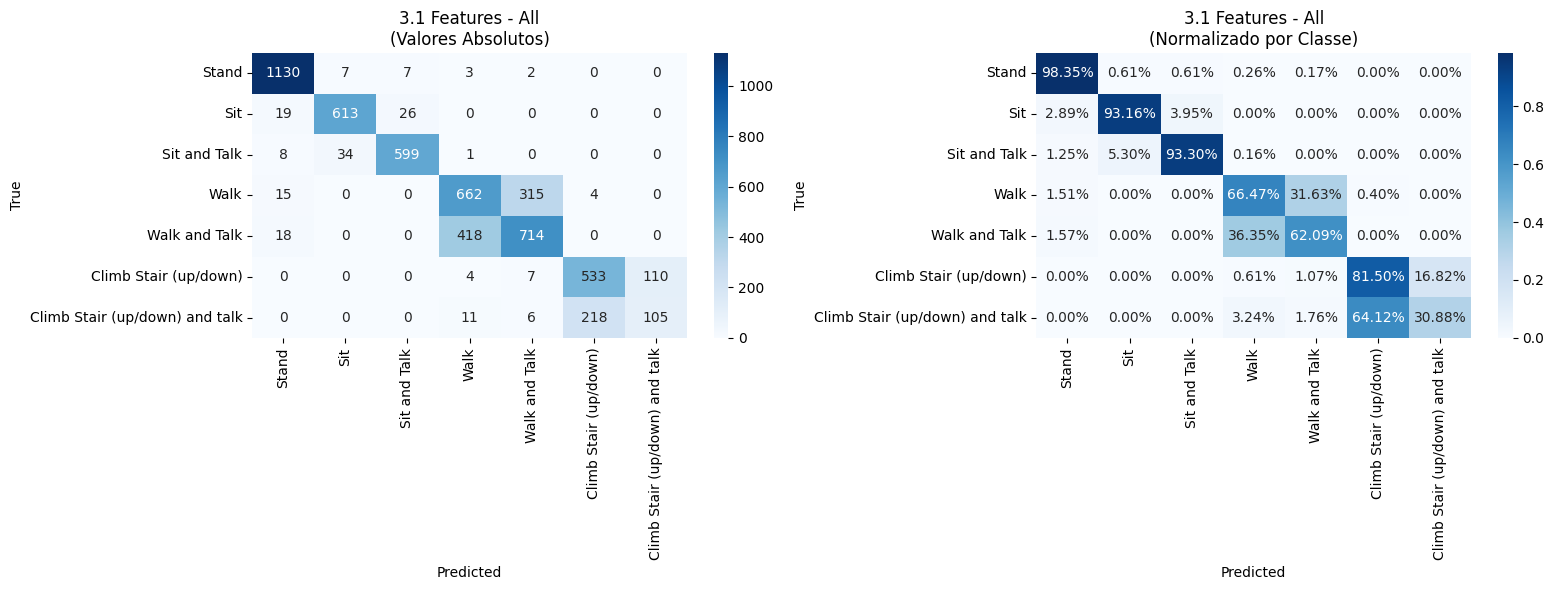


ANÁLISE DE ERROS: 3.1 Features - All

 RANKING DE DIFICULDADE (ordenado por F1-score):
--------------------------------------------------
1. Climb Stair (up/down) and talk F1: 0.378
2. Walk                 F1: 0.632
3. Walk and Talk        F1: 0.651
4. Climb Stair (up/down) F1: 0.757
5. Sit                  F1: 0.934
6. Sit and Talk         F1: 0.940
7. Stand                F1: 0.966

 CONFUSÕES MAIS FREQUENTES:
--------------------------------------------------
  Walk and Talk      → Walk               ( 418 erros, 36.3%)
  Walk               → Walk and Talk      ( 315 erros, 31.6%)
  Climb Stair (up/down) and talk → Climb Stair (up/down) ( 218 erros, 64.1%)
  Climb Stair (up/down) → Climb Stair (up/down) and talk ( 110 erros, 16.8%)
  Sit and Talk       → Sit                (  34 erros, 5.3%)
  Sit                → Sit and Talk       (  26 erros, 4.0%)
  Sit                → Stand              (  19 erros, 2.9%)
  Walk and Talk      → Stand              (  18 erros, 1.6%)
  Walk    

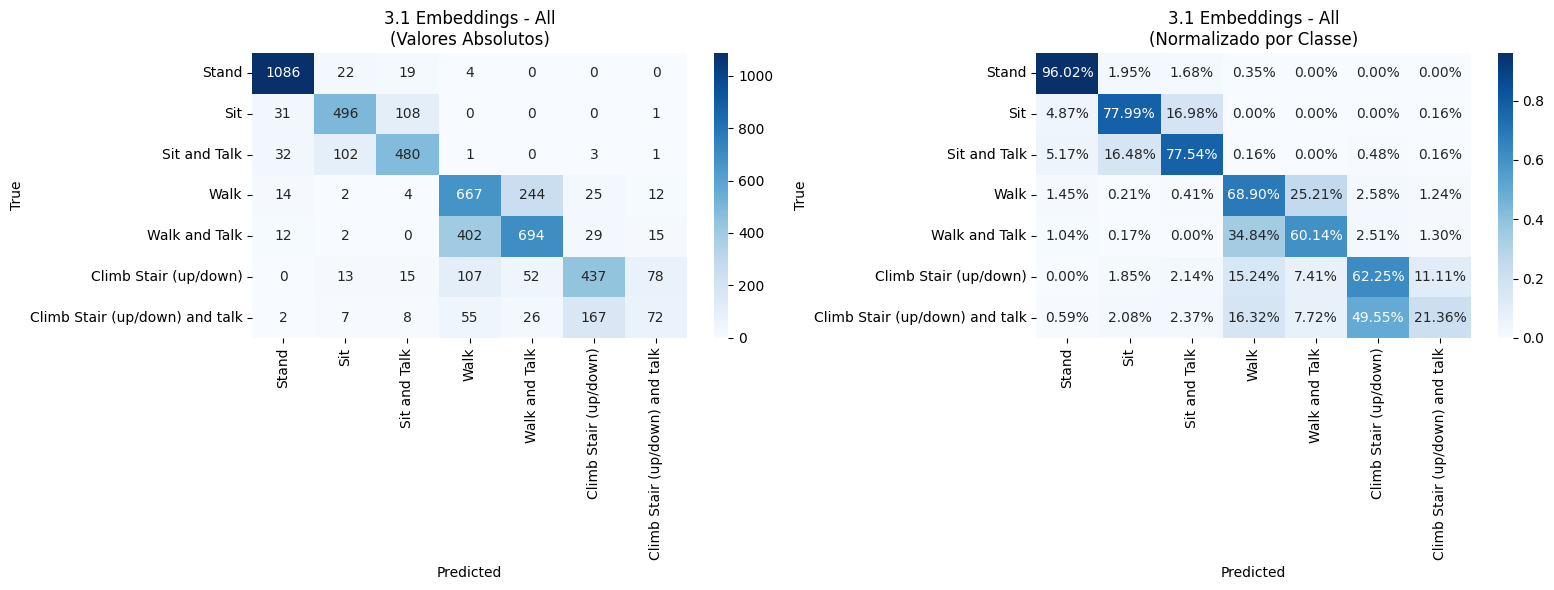


ANÁLISE DE ERROS: 3.1 Embeddings - All

 RANKING DE DIFICULDADE (ordenado por F1-score):
--------------------------------------------------
1. Climb Stair (up/down) and talk F1: 0.279
2. Walk                 F1: 0.605
3. Walk and Talk        F1: 0.640
4. Climb Stair (up/down) F1: 0.641
5. Sit and Talk         F1: 0.766
6. Sit                  F1: 0.775
7. Stand                F1: 0.941

 CONFUSÕES MAIS FREQUENTES:
--------------------------------------------------
  Walk and Talk      → Walk               ( 402 erros, 34.8%)
  Walk               → Walk and Talk      ( 244 erros, 25.2%)
  Climb Stair (up/down) and talk → Climb Stair (up/down) ( 167 erros, 49.6%)
  Sit                → Sit and Talk       ( 108 erros, 17.0%)
  Climb Stair (up/down) → Walk               ( 107 erros, 15.2%)
  Sit and Talk       → Sit                ( 102 erros, 16.5%)
  Climb Stair (up/down) → Climb Stair (up/down) and talk (  78 erros, 11.1%)
  Climb Stair (up/down) and talk → Walk               (  55 err

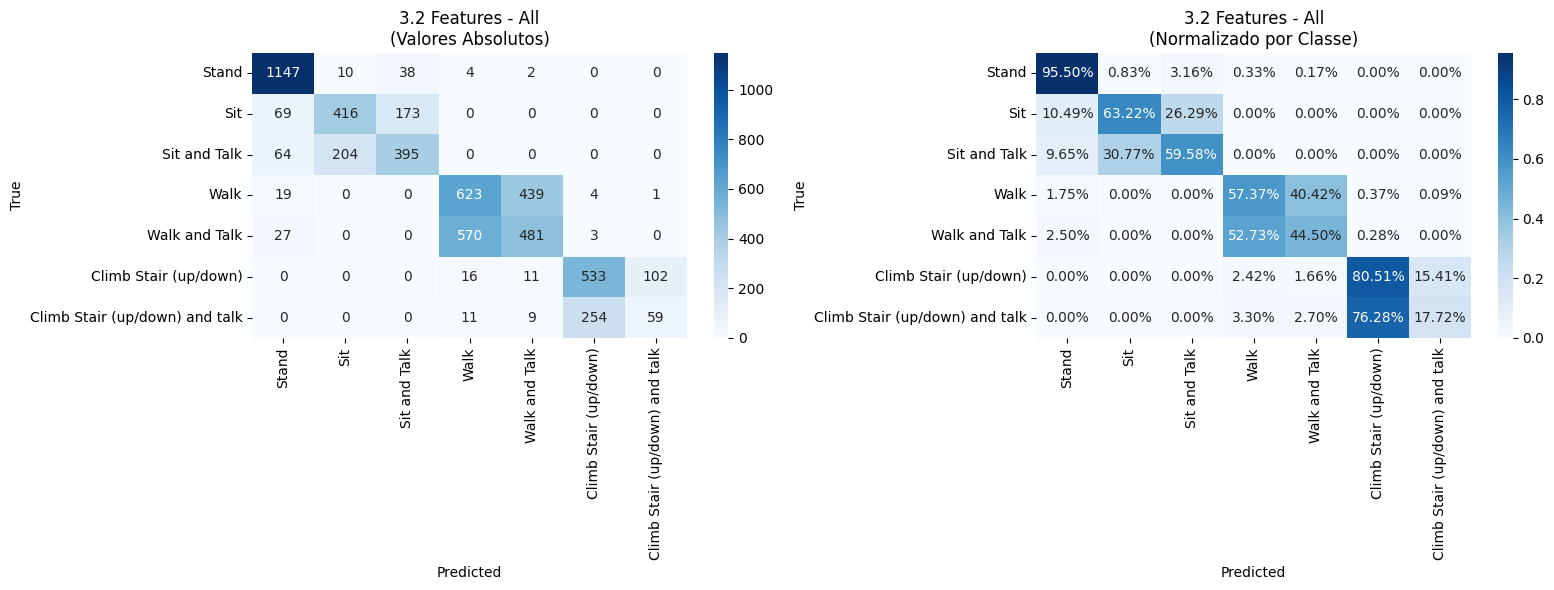


ANÁLISE DE ERROS: 3.2 Features - All

 RANKING DE DIFICULDADE (ordenado por F1-score):
--------------------------------------------------
1. Climb Stair (up/down) and talk F1: 0.238
2. Walk and Talk        F1: 0.476
3. Walk                 F1: 0.539
4. Sit and Talk         F1: 0.623
5. Sit                  F1: 0.646
6. Climb Stair (up/down) F1: 0.732
7. Stand                F1: 0.908

 CONFUSÕES MAIS FREQUENTES:
--------------------------------------------------
  Walk and Talk      → Walk               ( 570 erros, 52.7%)
  Walk               → Walk and Talk      ( 439 erros, 40.4%)
  Climb Stair (up/down) and talk → Climb Stair (up/down) ( 254 erros, 76.3%)
  Sit and Talk       → Sit                ( 204 erros, 30.8%)
  Sit                → Sit and Talk       ( 173 erros, 26.3%)
  Climb Stair (up/down) → Climb Stair (up/down) and talk ( 102 erros, 15.4%)
  Sit                → Stand              (  69 erros, 10.5%)
  Sit and Talk       → Stand              (  64 erros, 9.7%)
  Stand

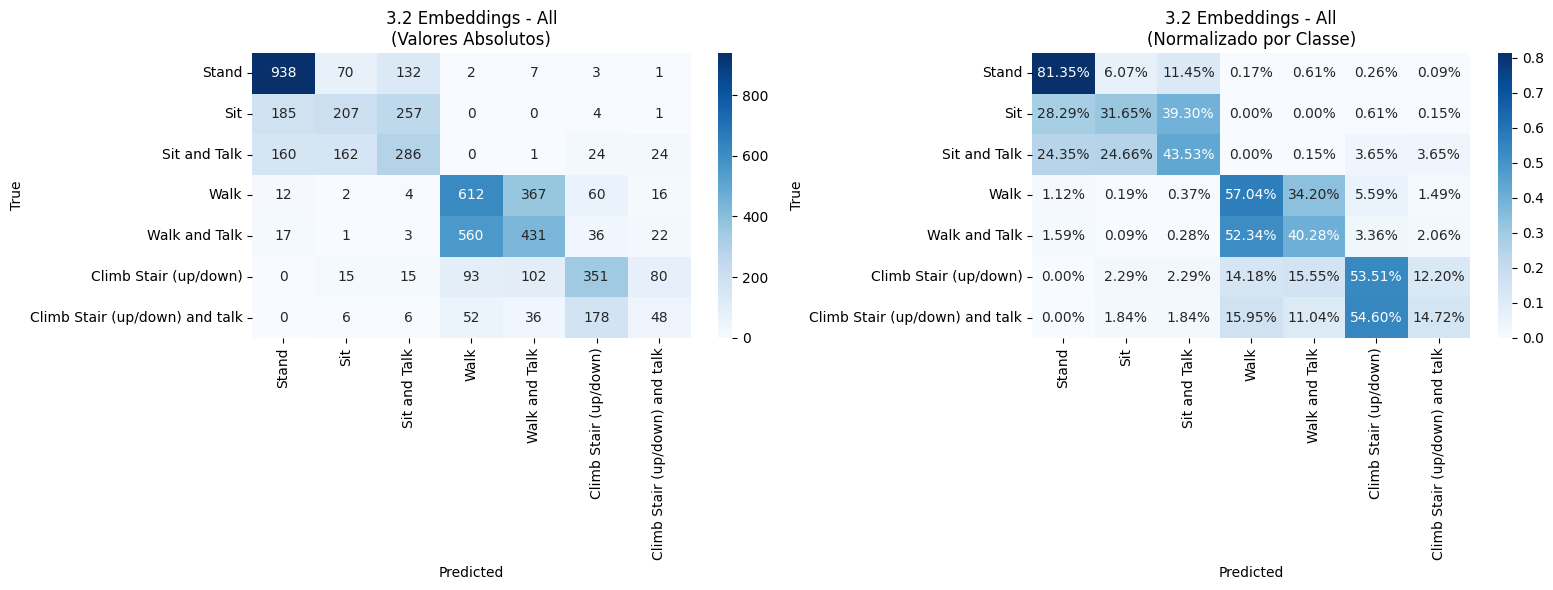


ANÁLISE DE ERROS: 3.2 Embeddings - All

 RANKING DE DIFICULDADE (ordenado por F1-score):
--------------------------------------------------
1. Climb Stair (up/down) and talk F1: 0.185
2. Sit                  F1: 0.371
3. Sit and Talk         F1: 0.421
4. Walk and Talk        F1: 0.428
5. Walk                 F1: 0.512
6. Climb Stair (up/down) F1: 0.535
7. Stand                F1: 0.761

 CONFUSÕES MAIS FREQUENTES:
--------------------------------------------------
  Walk and Talk      → Walk               ( 560 erros, 52.3%)
  Walk               → Walk and Talk      ( 367 erros, 34.2%)
  Sit                → Sit and Talk       ( 257 erros, 39.3%)
  Sit                → Stand              ( 185 erros, 28.3%)
  Climb Stair (up/down) and talk → Climb Stair (up/down) ( 178 erros, 54.6%)
  Sit and Talk       → Sit                ( 162 erros, 24.7%)
  Sit and Talk       → Stand              ( 160 erros, 24.4%)
  Stand              → Sit and Talk       ( 132 erros, 11.4%)
  Climb Stair (up/d

In [277]:
activity_names = {
    1: 'Stand',
    2: 'Sit', 
    3: 'Sit and Talk',
    4: 'Walk',
    5: 'Walk and Talk',
    6: 'Climb Stair (up/down)',
    7: 'Climb Stair (up/down) and talk'
}
def plot_confusion_matrix(y_true, y_pred, title, activity_names=activity_names):
    """Plota matriz de confusão com análise de erros"""
    cm = metrics.confusion_matrix(y_true, y_pred)
    labels = sorted(np.unique(np.concatenate([y_true, y_pred])))
    label_names = [activity_names.get(l, str(l)) for l in labels]
    
    # Normalizar por linha (recall por classe)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Matriz de confusão absoluta
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=label_names, yticklabels=label_names, ax=axes[0])
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('True')
    axes[0].set_title(f'{title}\n(Valores Absolutos)')
    
    # Matriz de confusão normalizada (%)
    sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names, ax=axes[1])
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('True')
    axes[1].set_title(f'{title}\n(Normalizado por Classe)')
    
    plt.tight_layout()
    plt.show()
    
    return cm, cm_normalized

def analyze_confusion_errors(y_true, y_pred, name, activity_names=activity_names):
    """Analisa os erros mais comuns na classificação"""
    cm = metrics.confusion_matrix(y_true, y_pred)
    labels = sorted(np.unique(np.concatenate([y_true, y_pred])))
    
    print(f"\n{'='*60}")
    print(f"ANÁLISE DE ERROS: {name}")
    print('='*60)
    
    # Calcular métricas por classe
    report = metrics.classification_report(y_true, y_pred, output_dict=True)
    
    # Identificar atividades mais difíceis (menor F1-score)
    class_f1 = []
    for label in labels:
        f1 = report[str(label)]['f1-score']
        class_f1.append((label, activity_names.get(label, str(label)), f1))
    
    class_f1.sort(key=lambda x: x[2])
    
    print("\n RANKING DE DIFICULDADE (ordenado por F1-score):")
    print("-"*50)
    for rank, (label, name_act, f1) in enumerate(class_f1, 1):
        print(f"{rank}. {name_act:<20} F1: {f1:.3f}")
    
    # Identificar confusões mais frequentes
    print("\n CONFUSÕES MAIS FREQUENTES:")
    print("-"*50)
    
    confusions = []
    for i, true_label in enumerate(labels):
        for j, pred_label in enumerate(labels):
            if i != j and cm[i, j] > 0:
                confusions.append({
                    'true': activity_names.get(true_label, str(true_label)),
                    'pred': activity_names.get(pred_label, str(pred_label)),
                    'count': cm[i, j],
                    'percent': cm[i, j] / cm[i].sum() * 100
                })
    
    confusions.sort(key=lambda x: x['count'], reverse=True)
    
    for conf in confusions[:10]:  # Top 10 confusões
        print(f"  {conf['true']:<18} → {conf['pred']:<18} ({conf['count']:>4} erros, {conf['percent']:.1f}%)")
    
    return class_f1, confusions

# Plotar matrizes de confusão para os melhores modelos de cada split
print("\n" + "="*80)
print("5.2 - ANÁLISE DAS MATRIZES DE CONFUSÃO")
print("="*80)

# Selecionar modelos para análise detalhada
models_to_analyze = [
    ("3.1 Features - All", 0),
    ("3.1 Embeddings - All", 3),
    ("3.2 Features - All", 6),
    ("3.2 Embeddings - All", 9),
]

all_analysis = {}

for name, idx in models_to_analyze:
    result = all_results[idx]
    
    # Plot confusion matrix
    cm, cm_norm = plot_confusion_matrix(result['y_true'], result['y_pred'], name)
    
    # Analyze errors
    class_f1, confusions = analyze_confusion_errors(result['y_true'], result['y_pred'], name)
    
    all_analysis[name] = {
        'cm': cm,
        'cm_normalized': cm_norm,
        'class_f1': class_f1,
        'confusions': confusions
    }


COMPARAÇÃO DE PERFORMANCE POR ATIVIDADE


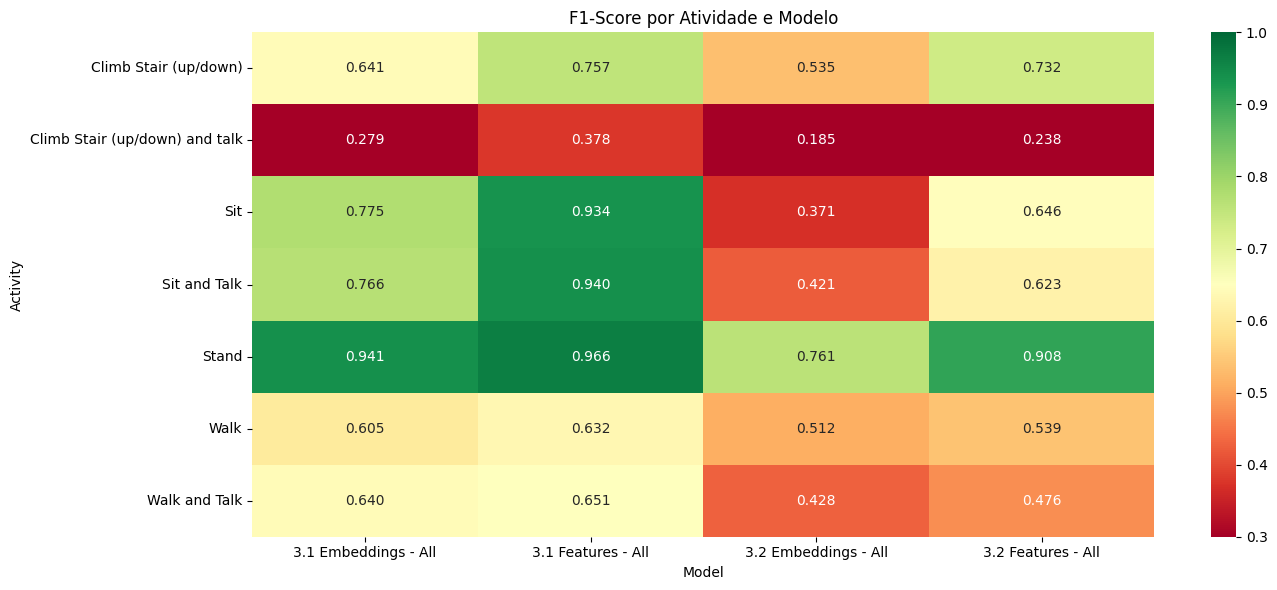


MÉDIA DE F1-SCORE POR ATIVIDADE (todos os modelos):
--------------------------------------------------
 Climb Stair (up/down) and talk Média F1: 0.270
 Walk and Talk        Média F1: 0.549
 Walk                 Média F1: 0.572
 Climb Stair (up/down) Média F1: 0.666
 Sit                  Média F1: 0.682
 Sit and Talk         Média F1: 0.687
 Stand                Média F1: 0.894


In [278]:
# === Comparação entre modelos ===

def compare_class_performance(all_results, activity_names=activity_names):
    """Compara performance por classe entre diferentes modelos"""
    
    print("\n" + "="*80)
    print("COMPARAÇÃO DE PERFORMANCE POR ATIVIDADE")
    print("="*80)
    
    # Preparar dados
    models = ["3.1 Features - All", "3.1 Embeddings - All", 
              "3.2 Features - All", "3.2 Embeddings - All"]
    indices = [0, 3, 6, 9]
    
    # Criar DataFrame com F1-scores por classe
    data = []
    for name, idx in zip(models, indices):
        result = all_results[idx]
        report = metrics.classification_report(result['y_true'], result['y_pred'], output_dict=True)
        
        for label in sorted(np.unique(result['y_true'])):
            data.append({
                'Model': name,
                'Activity': activity_names.get(label, str(label)),
                'F1-Score': report[str(label)]['f1-score'],
                'Precision': report[str(label)]['precision'],
                'Recall': report[str(label)]['recall']
            })
    
    df = pd.DataFrame(data)
    
    # Plot comparativo
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Pivot para heatmap
    pivot_df = df.pivot(index='Activity', columns='Model', values='F1-Score')
    
    sns.heatmap(pivot_df, annot=True, fmt='.3f', cmap='RdYlGn', 
                vmin=0.3, vmax=1.0, ax=ax)
    ax.set_title('F1-Score por Atividade e Modelo')
    plt.tight_layout()
    plt.show()
    
    # Identificar atividades mais problemáticas globalmente
    print("\nMÉDIA DE F1-SCORE POR ATIVIDADE (todos os modelos):")
    print("-"*50)
    avg_by_activity = df.groupby('Activity')['F1-Score'].mean().sort_values()
    
    for activity, f1_avg in avg_by_activity.items():
        print(f" {activity:<20} Média F1: {f1_avg:.3f}")
    
    return df

# Executar comparação
comparison_df = compare_class_performance(all_results)

In [279]:
# === Resumo em Markdown para o relatório ===

def generate_summary_markdown(all_results, activity_names=activity_names):
    """Gera resumo textual da análise"""
    
    print("\n" + "="*80)
    print("RESUMO DA ANÁLISE (para incluir no relatório)")
    print("="*80)
    
    # Melhor modelo geral
    best_model = max(all_results, key=lambda x: x['test_f1_macro'])
    print(f"\n MELHOR MODELO: {best_model['name']}")
    print(f"   F1 Macro: {best_model['test_f1_macro']:.4f}")
    print(f"   Accuracy: {best_model['test_acc']:.4f}")
    
    # Análise do melhor modelo
    report = metrics.classification_report(best_model['y_true'], best_model['y_pred'], output_dict=True)
    
    # Atividade mais fácil
    best_class = max(range(1, 8), key=lambda x: report[str(x)]['f1-score'] if str(x) in report else 0)
    worst_class = min(range(1, 8), key=lambda x: report[str(x)]['f1-score'] if str(x) in report else 1)
    
    print(f"\n Atividade MAIS FÁCIL: {activity_names[best_class]}")
    print(f"   F1: {report[str(best_class)]['f1-score']:.3f}")
    
    print(f"\n Atividade MAIS DIFÍCIL: {activity_names[worst_class]}")
    print(f"   F1: {report[str(worst_class)]['f1-score']:.3f}")
    
    # Confusões principais
    cm = metrics.confusion_matrix(best_model['y_true'], best_model['y_pred'])
    labels = sorted(np.unique(best_model['y_true']))
    
    print("\n  PRINCIPAIS CONFUSÕES:")
    confusions = []
    for i, true_label in enumerate(labels):
        for j, pred_label in enumerate(labels):
            if i != j and cm[i, j] > 0:
                confusions.append((true_label, pred_label, cm[i, j]))
    
    confusions.sort(key=lambda x: x[2], reverse=True)
    for true_l, pred_l, count in confusions[:5]:
        print(f"   • {activity_names[true_l]} confundido com {activity_names[pred_l]}: {count} casos")

generate_summary_markdown(all_results)


RESUMO DA ANÁLISE (para incluir no relatório)

 MELHOR MODELO: 3.1 Features - All
   F1 Macro: 0.7513
   Accuracy: 0.7794

 Atividade MAIS FÁCIL: Stand
   F1: 0.966

 Atividade MAIS DIFÍCIL: Climb Stair (up/down) and talk
   F1: 0.378

  PRINCIPAIS CONFUSÕES:
   • Walk and Talk confundido com Walk: 418 casos
   • Walk confundido com Walk and Talk: 315 casos
   • Climb Stair (up/down) and talk confundido com Climb Stair (up/down): 218 casos
   • Climb Stair (up/down) confundido com Climb Stair (up/down) and talk: 110 casos
   • Sit and Talk confundido com Sit: 34 casos


### 5.3 Perform hypothesis testing to compare the models
Is the best model statistically significantly better than the others? Justify the choice of the statistical tests you use. (NOTE: repeat the train-validation-test split several times to obtain the performance distributions of each model)

### Testar modelo com diversos splits

In [239]:
def full_evaluation_pipeline(X_train, y_train, X_val, y_val, X_test, y_test, name=""):
    """Pipeline completo: tuning + re-treino + avaliação final com múltiplas métricas"""
    
    # 1. Encontrar melhor k
    best_k, val_f1, results = find_best_k(X_train, y_train, X_val, y_val)
    print(f"\n{'='*50}")
    print(f"[{name}]")
    print(f"Melhor k: {best_k} (F1 macro validação: {val_f1:.4f})")
    
    # 2. Re-treinar com train + validation
    X_train_full = np.vstack([X_train, X_val])
    y_train_full = np.concatenate([y_train, y_val])
    
    knn_final = KNNClassifierGPU(k=best_k)
    knn_final.fit(X_train_full, y_train_full)
    
    # 3. Avaliar no test com múltiplas métricas
    y_pred_test = knn_final.predict(X_test)
    
    test_acc = metrics.accuracy_score(y_test, y_pred_test)
    test_f1_macro = metrics.f1_score(y_test, y_pred_test, average='macro')
    test_f1_weighted = metrics.f1_score(y_test, y_pred_test, average='weighted')
    test_precision = metrics.precision_score(y_test, y_pred_test, average='macro')
    test_recall = metrics.recall_score(y_test, y_pred_test, average='macro')
    
    print(f"\n--- Métricas no TEST ---")
    print(f"Accuracy:     {test_acc:.4f}")
    print(f"F1 Macro:     {test_f1_macro:.4f}")
    print(f"F1 Weighted:  {test_f1_weighted:.4f}")
    print(f"Precision:    {test_precision:.4f}")
    print(f"Recall:       {test_recall:.4f}")
    
    print(f"\nClassification Report:")
    print(metrics.classification_report(y_test, y_pred_test))
    print(f"Confusion Matrix:")
    print(metrics.confusion_matrix(y_test, y_pred_test))
    
    return {
        'name': name,
        'best_k': best_k,
        'val_f1': val_f1,
        'test_acc': test_acc,
        'test_f1_macro': test_f1_macro,
        'test_f1_weighted': test_f1_weighted,
        'test_precision': test_precision,
        'test_recall': test_recall,
        'y_pred': y_pred_test,
        'y_true': y_test,
        'k_results': results
    }

In [280]:
# Função que recebe os dados (features ou embeddings), lista de valores a testar entre treino e treino e o segundo split para a validação e teste
def test_with_split_60_20_20(dataset, feat):
    splits_ALL= []
    splits_PCA= []
    splits_ReliefF= []
   
    for seed in range(32, 62):
        # if feat == 1 -> features else embeddings
        if feat == 1:
            train,val,test = split_features_dataset(dataset, random_state=seed)
        else:
            train,val,test = split_embeddings_dataset(dataset, random_state=seed)
        
        X_train = train[:, 1:-1]  # Excluir coluna individuo e label
        y_train = train[:, -1]
        X_val = val[:, 1:-1]
        y_val = val[:, -1]
        X_test = test[:, 1:-1]
        y_test = test[:, -1]
        
        # Normalizar
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_val = scaler.transform(X_val)
        X_test = scaler.transform(X_test)

        #ALL FEATURES
        best_k_ALL, _, _ = find_best_k(X_train, y_train, X_val, y_val)
        knngpu = KNNClassifierGPU(k=best_k_ALL)
        knngpu.fit(np.vstack((X_train,X_val)), np.concatenate((y_train,y_val)))
        y_pred_ALL = knngpu.predict(X_test)
        f1_ALL=metrics.f1_score(y_test, y_pred_ALL, average='macro')

        #PCA
        X_train_PCA, X_val_PCA, X_test_PCA = apply_pca(X_train, X_val, X_test)
        best_k_PCA, _, _ = find_best_k(X_train_PCA, y_train, X_val_PCA, y_val)
        knngpu = KNNClassifierGPU(k=best_k_PCA)
        knngpu.fit(np.vstack((X_train_PCA,X_val_PCA)), np.concatenate((y_train,y_val)))
        y_pred_PCA = knngpu.predict(X_test_PCA)
        f1_PCA=metrics.f1_score(y_test, y_pred_PCA, average='macro')

        #ReliefF
        X_train_ReliefF, X_val_ReliefF, X_test_ReliefF, _ = apply_relieff_pipeline(
        X_train, y_train, X_val, X_test
        )
        best_k_ReliefF, _, _ = find_best_k(X_train_ReliefF, y_train, X_val_ReliefF, y_val) 
        knn_final = KNNClassifierGPU(k=best_k_ReliefF)
        knn_final.fit(np.vstack((X_train_ReliefF,X_val_ReliefF)), np.concatenate((y_train,y_val)))
        y_pred_ReliefF = knn_final.predict(X_test_ReliefF)
        f1_ReliefF=metrics.f1_score(y_test, y_pred_ReliefF, average='macro')

        splits_ALL.append({
            'seed': seed,
            'best_k': best_k_ALL,
            'f1': f1_ALL,
            'results': metrics.classification_report(y_test, y_pred_ALL, output_dict=True)
        })
        splits_PCA.append({
            'seed': seed,   
            'best_k': best_k_PCA,
            'f1': f1_PCA,   
            'results': metrics.classification_report(y_test, y_pred_PCA, output_dict=True)
        })

        splits_ReliefF.append({
            'seed': seed,
            'best_k': best_k_ReliefF,
            'f1': f1_ReliefF,
            'results': metrics.classification_report(y_test, y_pred_ReliefF, output_dict=True)})
        
    return splits_ALL, splits_PCA, splits_ReliefF

res_ALL_feat_60_20_20, res_PCA_feat_60_20_20, res_ReliefF_feat_60_20_20 = test_with_split_60_20_20(feature_dataset, feat=1)
res_ALL_emb_60_20_20, res_PCA_emb_60_20_20, res_ReliefF_emb_60_20_20 = test_with_split_60_20_20(embeddings_dataset, feat=0)

KNN está a correr com: cuda
KNN está a correr com: cuda
PCA - Número de componentes mantidos: 53
KNN está a correr com: cuda
KNN está a correr com: cuda
ReliefF - Top 15 features selecionadas
KNN está a correr com: cuda
KNN está a correr com: cuda
KNN está a correr com: cuda
KNN está a correr com: cuda
PCA - Número de componentes mantidos: 52
KNN está a correr com: cuda
KNN está a correr com: cuda
ReliefF - Top 15 features selecionadas
KNN está a correr com: cuda
KNN está a correr com: cuda
KNN está a correr com: cuda
KNN está a correr com: cuda
PCA - Número de componentes mantidos: 53
KNN está a correr com: cuda
KNN está a correr com: cuda
ReliefF - Top 15 features selecionadas
KNN está a correr com: cuda
KNN está a correr com: cuda
KNN está a correr com: cuda
KNN está a correr com: cuda
PCA - Número de componentes mantidos: 53
KNN está a correr com: cuda
KNN está a correr com: cuda
ReliefF - Top 15 features selecionadas
KNN está a correr com: cuda
KNN está a correr com: cuda
KNN está

In [281]:
all_participants = np.arange(15)

def filter_by_participants(dataset, participants):
    mask = np.isin(dataset[:, 0], participants)
    return dataset[mask]

def split_data_9_3_3(dataset, seed):
    np.random.seed(seed)
    shuffled = np.random.permutation(all_participants)
    train_participants = shuffled[:9]
    val_participants   = shuffled[9:12]
    test_participants  = shuffled[12:]

    train_subj = filter_by_participants(dataset, train_participants)
    val_subj   = filter_by_participants(dataset, val_participants)
    test_subj  = filter_by_participants(dataset, test_participants)

    return train_subj, val_subj, test_subj

def test_with_split_9_3_3(dataset):
    splits_ALL = []
    splits_PCA = []
    splits_ReliefF = []
   
    for seed in range(32, 62):
        train, val, test = split_data_9_3_3(dataset, seed)
        X_train = train[:, 1:-1]  # Excluir coluna individuo e label
        y_train = train[:, -1]
        X_val = val[:, 1:-1]
        y_val = val[:, -1]
        X_test = test[:, 1:-1]
        y_test = test[:, -1]

        # Normalizar
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_val = scaler.transform(X_val)
        X_test = scaler.transform(X_test)

        # ALL FEATURES/EMBEDDINGS
        best_k_ALL, _, _ = find_best_k(X_train, y_train, X_val, y_val)
        knngpu = KNNClassifierGPU(k=best_k_ALL)
        knngpu.fit(np.vstack((X_train, X_val)), np.concatenate((y_train, y_val)))
        y_pred_ALL = knngpu.predict(X_test)
        f1_ALL = metrics.f1_score(y_test, y_pred_ALL, average='macro')

        # PCA
        X_train_PCA, X_val_PCA, X_test_PCA = apply_pca(X_train, X_val, X_test)
        best_k_PCA, _, _ = find_best_k(X_train_PCA, y_train, X_val_PCA, y_val)
        knngpu = KNNClassifierGPU(k=best_k_PCA)
        knngpu.fit(np.vstack((X_train_PCA, X_val_PCA)), np.concatenate((y_train, y_val)))
        y_pred_PCA = knngpu.predict(X_test_PCA)
        f1_PCA = metrics.f1_score(y_test, y_pred_PCA, average='macro')

        # ReliefF
        X_train_ReliefF, X_val_ReliefF, X_test_ReliefF, _ = apply_relieff_pipeline(
            X_train, y_train, X_val, X_test
        )
        best_k_ReliefF, _, _ = find_best_k(X_train_ReliefF, y_train, X_val_ReliefF, y_val)
        knn_final = KNNClassifierGPU(k=best_k_ReliefF)
        knn_final.fit(np.vstack((X_train_ReliefF, X_val_ReliefF)), np.concatenate((y_train, y_val)))
        y_pred_ReliefF = knn_final.predict(X_test_ReliefF)
        f1_ReliefF = metrics.f1_score(y_test, y_pred_ReliefF, average='macro')

        # Guardar resultados
        splits_ALL.append({
            'seed': seed,
            'best_k': best_k_ALL,
            'f1': f1_ALL,
            'results': metrics.classification_report(y_test, y_pred_ALL, output_dict=True)
        })
        splits_PCA.append({
            'seed': seed,
            'best_k': best_k_PCA,
            'f1': f1_PCA,
            'results': metrics.classification_report(y_test, y_pred_PCA, output_dict=True)
        })
        splits_ReliefF.append({
            'seed': seed,
            'best_k': best_k_ReliefF,
            'f1': f1_ReliefF,
            'results': metrics.classification_report(y_test, y_pred_ReliefF, output_dict=True)
        })
        
    return splits_ALL, splits_PCA, splits_ReliefF

# Executar para features e embeddings
res_ALL_feat_9_3_3, res_PCA_feat_9_3_3, res_ReliefF_feat_9_3_3 = test_with_split_9_3_3(feature_dataset)
res_ALL_emb_9_3_3, res_PCA_emb_9_3_3, res_ReliefF_emb_9_3_3 = test_with_split_9_3_3(embeddings_dataset)

KNN está a correr com: cuda
KNN está a correr com: cuda
PCA - Número de componentes mantidos: 52
KNN está a correr com: cuda
KNN está a correr com: cuda
ReliefF - Top 15 features selecionadas
KNN está a correr com: cuda
KNN está a correr com: cuda
KNN está a correr com: cuda
KNN está a correr com: cuda
PCA - Número de componentes mantidos: 52
KNN está a correr com: cuda
KNN está a correr com: cuda
ReliefF - Top 15 features selecionadas
KNN está a correr com: cuda
KNN está a correr com: cuda
KNN está a correr com: cuda
KNN está a correr com: cuda
PCA - Número de componentes mantidos: 50
KNN está a correr com: cuda
KNN está a correr com: cuda
ReliefF - Top 15 features selecionadas
KNN está a correr com: cuda
KNN está a correr com: cuda
KNN está a correr com: cuda
KNN está a correr com: cuda
PCA - Número de componentes mantidos: 51
KNN está a correr com: cuda
KNN está a correr com: cuda
ReliefF - Top 15 features selecionadas
KNN está a correr com: cuda
KNN está a correr com: cuda
KNN está

In [282]:
f1scores_ALL_feat_60_20_20 = [split['f1'] for split in res_ALL_feat_60_20_20]
f1scores_PCA_feat_60_20_20 = [split['f1'] for split in res_PCA_feat_60_20_20]
f1scores_ReliefF_feat_60_20_20 = [split['f1'] for split in res_ReliefF_feat_60_20_20]

f1scores_ALL_emb_60_20_20 = [split['f1'] for split in res_ALL_emb_60_20_20]
f1scores_PCA_emb_60_20_20 = [split['f1'] for split in res_PCA_emb_60_20_20]
f1scores_ReliefF_emb_60_20_20 = [split['f1'] for split in res_ReliefF_emb_60_20_20]

f1scores_ALL_feat_9_3_3 = [split['f1'] for split in res_ALL_feat_9_3_3]
f1scores_PCA_feat_9_3_3 = [split['f1'] for split in res_PCA_feat_9_3_3]
f1scores_ReliefF_feat_9_3_3 = [split['f1'] for split in res_ReliefF_feat_9_3_3]

f1scores_ALL_emb_9_3_3 = [split['f1'] for split in res_ALL_emb_9_3_3]
f1scores_PCA_emb_9_3_3 = [split['f1'] for split in res_PCA_emb_9_3_3]
f1scores_ReliefF_emb_9_3_3 = [split['f1'] for split in res_ReliefF_emb_9_3_3]

In [283]:
from scipy.stats import shapiro

def test_normalidade(scores_dict):
    """Testa normalidade das distribuições de F1-scores com Shapiro-Wilk"""
    
    print("TESTE DE NORMALIDADE (Shapiro-Wilk)")
    print("Se p > 0.05 → Dados normais")
    print("-"*50)
    
    for name, scores in scores_dict.items():
        stat, p = shapiro(scores)
        resultado = "Normal" if p > 0.05 else "Não Normal"
        print(f"{name:<35} p={p:.4f} → {resultado}")

# Criar dicionário com todos os resultados
all_f1_scores = {
    # Split 60-20-20 - Features
    'Feat ALL 60-20-20': [split['f1'] for split in res_ALL_feat_60_20_20],
    'Feat PCA 60-20-20': [split['f1'] for split in res_PCA_feat_60_20_20],
    'Feat ReliefF 60-20-20': [split['f1'] for split in res_ReliefF_feat_60_20_20],
    # Split 60-20-20 - Embeddings
    'Emb ALL 60-20-20': [split['f1'] for split in res_ALL_emb_60_20_20],
    'Emb PCA 60-20-20': [split['f1'] for split in res_PCA_emb_60_20_20],
    'Emb ReliefF 60-20-20': [split['f1'] for split in res_ReliefF_emb_60_20_20],
    # Split 9-3-3 - Features
    'Feat ALL 9-3-3': [split['f1'] for split in res_ALL_feat_9_3_3],
    'Feat PCA 9-3-3': [split['f1'] for split in res_PCA_feat_9_3_3],
    'Feat ReliefF 9-3-3': [split['f1'] for split in res_ReliefF_feat_9_3_3],
    # Split 9-3-3 - Embeddings
    'Emb ALL 9-3-3': [split['f1'] for split in res_ALL_emb_9_3_3],
    'Emb PCA 9-3-3': [split['f1'] for split in res_PCA_emb_9_3_3],
    'Emb ReliefF 9-3-3': [split['f1'] for split in res_ReliefF_emb_9_3_3],
}

# Testar normalidade de todos
test_normalidade(all_f1_scores)

# Mostrar estatísticas descritivas
print("\n" + "="*70)
print("ESTATÍSTICAS DESCRITIVAS")
print("="*70)
print(f"{'Modelo':<35} {'Média':<10} {'Std':<10} {'Min':<10} {'Max':<10}")
print("-"*70)
for name, scores in all_f1_scores.items():
    print(f"{name:<35} {np.mean(scores):<10.4f} {np.std(scores):<10.4f} {np.min(scores):<10.4f} {np.max(scores):<10.4f}")

TESTE DE NORMALIDADE (Shapiro-Wilk)
Se p > 0.05 → Dados normais
--------------------------------------------------
Feat ALL 60-20-20                   p=0.9764 → Normal
Feat PCA 60-20-20                   p=0.3412 → Normal
Feat ReliefF 60-20-20               p=0.5714 → Normal
Emb ALL 60-20-20                    p=0.9698 → Normal
Emb PCA 60-20-20                    p=0.7997 → Normal
Emb ReliefF 60-20-20                p=0.2771 → Normal
Feat ALL 9-3-3                      p=0.4347 → Normal
Feat PCA 9-3-3                      p=0.5158 → Normal
Feat ReliefF 9-3-3                  p=0.1169 → Normal
Emb ALL 9-3-3                       p=0.2797 → Normal
Emb PCA 9-3-3                       p=0.3854 → Normal
Emb ReliefF 9-3-3                   p=0.6392 → Normal

ESTATÍSTICAS DESCRITIVAS
Modelo                              Média      Std        Min        Max       
----------------------------------------------------------------------
Feat ALL 60-20-20                   0.7362     0.0064     0.

-------------------------------------------------------------------------------

In [284]:
from scipy.stats import f_oneway, ttest_ind
from itertools import combinations

def comparar_():
    
    # 1. ANOVA - Comparação global
    f_stat, anova_p = f_oneway(*all_f1_scores.values())
    
    print("="*60)
    print("ANOVA (comparação global entre os 4 grupos)")
    print("="*60)
    print(f"F={f_stat:.4f}, p={anova_p:.6f}")
    print("Há diferença significativa entre grupos?", "SIM" if anova_p < 0.05 else "NÃO")
    
    # 2. Se ANOVA significativo → Post-hoc t-tests com correção Bonferroni
    if anova_p < 0.05:
        print("\n" + "="*60)
        print("POST-HOC: t-tests par a par (Bonferroni)")
        print("="*60)
        
        # Número de comparações = C(4,2) = 6
        n_comparisons = 6
        alpha_bonferroni = 0.05 / n_comparisons  # 0.0083
        print(f"Alpha corrigido (Bonferroni): {alpha_bonferroni:.4f}")
        print("-"*60)
        
        pairs = list(combinations(all_f1_scores.keys(), 2))
        
        for name1, name2 in pairs:
            scores1, scores2 = all_f1_scores[name1], all_f1_scores[name2]
            t_stat, t_p = ttest_ind(scores1, scores2)
            
            # Significância com correção
            sig = "***" if t_p < 0.001 else "**" if t_p < alpha_bonferroni else "*" if t_p < 0.05 else ""
            diff = "SIM" if t_p < alpha_bonferroni else "NÃO"
            
            print(f"{name1:<15} vs {name2:<15}: t={t_stat:>7.3f}, p={t_p:.4f} {sig:<3} → Diferença: {diff}")
    else:
        print("\nANOVA não significativo → Não há evidência de diferença entre grupos.")

comparar_()

ANOVA (comparação global entre os 4 grupos)
F=1786.3028, p=0.000000
Há diferença significativa entre grupos? SIM

POST-HOC: t-tests par a par (Bonferroni)
Alpha corrigido (Bonferroni): 0.0083
------------------------------------------------------------
Feat ALL 60-20-20 vs Feat PCA 60-20-20: t=  6.848, p=0.0000 *** → Diferença: SIM
Feat ALL 60-20-20 vs Feat ReliefF 60-20-20: t=  0.494, p=0.6230     → Diferença: NÃO
Feat ALL 60-20-20 vs Emb ALL 60-20-20: t= 42.611, p=0.0000 *** → Diferença: SIM
Feat ALL 60-20-20 vs Emb PCA 60-20-20: t= 85.199, p=0.0000 *** → Diferença: SIM
Feat ALL 60-20-20 vs Emb ReliefF 60-20-20: t= 74.284, p=0.0000 *** → Diferença: SIM
Feat ALL 60-20-20 vs Feat ALL 9-3-3 : t= 39.865, p=0.0000 *** → Diferença: SIM
Feat ALL 60-20-20 vs Feat PCA 9-3-3 : t= 42.829, p=0.0000 *** → Diferença: SIM
Feat ALL 60-20-20 vs Feat ReliefF 9-3-3: t= 48.774, p=0.0000 *** → Diferença: SIM
Feat ALL 60-20-20 vs Emb ALL 9-3-3  : t= 90.221, p=0.0000 *** → Diferença: SIM
Feat ALL 60-20-20 

## 6 - Deployment
Pick the best model from question 5 and make a function that receives a numpy array of shape 256 lines and 9 columns (acc x y z, gyr x y z, mag x y z) and performs all the necessary steps to return a classification from the model (normalization, feature extraction / embeddings generation, [PCA, Feature Selection], classification).

-------------------------------------------------------------------------------

## 7 - Go further
Discuss what can be done more to improve your classification system.

### 7.1 (BONUS) Implement and evaluate some of those ideas!